The code in this notebook is based on the original PyTorch3D tutorial: https://pytorch3d.org/tutorials/render_textured_meshes

---


# Render a textured mesh & verify coordinate systems (PyTorch3D ↔ OpenCV)

This notebook will:

1. **Load** a textured mesh from an `.obj`.
2. **Configure** a PyTorch3D renderer (camera, rasterizer, shader, lights).
3. **Render** the mesh and **tune** settings (lighting, materials, camera pose).
4. **Batch-render** multiple viewpoints efficiently using PyTorch3D’s batched API.
5. **Validate coordinates** with small tests/overlays to understand PyTorch3D’s camera frame and how it relates to OpenCV.




# ⚙️ Notebook Environment Selection (Manual Switch)

There is no reliable way to automatically detect whether this notebook is running:

- in **Colab (web UI)**  
- or in **VS Code connected to a remote Colab runtime**

Because of this limitation, we use a **manual flag** to explicitly define the environment.

---

## 🛠️ How to use

In the next code cell, set:

```python
RUNNING_IN_VSCODE = True

In [327]:
import os

#@title Check the box to indicate the IDE environment you want to use:
#@markdown
#@markdown If editing the code outside Colab, just change
#@markdown `RUNNING_IN_VSCODE = False` to `RUNNING_IN_VSCODE = True`.


# ── Set this manually ──────────────────────
RUNNING_IN_VSCODE = False          #@param {type:"boolean"}
# ───────────────────────────────────────────

os.environ['NOTEBOOK_ENV'] = 'vscode' if RUNNING_IN_VSCODE else 'colab'
print("Environment:", os.environ['NOTEBOOK_ENV'])





from IPython.display import HTML, display
import os

env = os.environ.get("NOTEBOOK_ENV", "unknown")

if env == "vscode":
    display(HTML("""
    <div style="
        padding: 14px 18px;
        margin-top: 8px;
        border-left: 6px solid #f59e0b;
        border-radius: 8px;
        background-color: #fff7ed;
        box-shadow: 0 3px 10px rgba(0,0,0,0.10);
        font-family: 'Helvetica Neue', Arial, sans-serif;
        font-size: 15px;
        color: #7c2d12;
    ">
        ⚠️ <b>VS Code Mode Detected</b><br>
        Colab Secrets are <b>not available</b> in this environment.<br>
        You may need to manually provide credentials (e.g., GitHub token).
    </div>
    """))
else:
    display(HTML("""
    <div style="
        padding: 14px 18px;
        margin-top: 8px;
        border-left: 6px solid #f59e0b;
        border-radius: 8px;
        background-color: #fff7ed;
        box-shadow: 0 3px 10px rgba(0,0,0,0.10);
        font-family: 'Helvetica Neue', Arial, sans-serif;
        font-size: 15px;
        color: #7c2d12;
    ">
        ⚠️ <b>Running in Web-Based Colab</b><br>
        GitHub credentials (i.e., personal token) is stored in Colab Secrets in this environment.<br>
    </div>
    """))

Environment: colab


time: 4.55 ms (started: 2026-04-30 03:04:41 +00:00)


# 🔐 Secure GitHub Token Prompt (VS Code + Remote Colab)

When running this notebook from **VS Code connected to a remote Colab runtime**,  
Colab Secrets are not accessible. In this case, we must manually provide the GitHub token.

Instead of hardcoding the token (unsafe), we use a secure prompt.

---

## 📌 Instructions

1.  Open your Notion workspace (**This step is in my case specifically**):

    - Token location (my case): `Notion → Main page → Programming → GitHub Token`

2. Copy your GitHub Personal Access Token.

3. Run the code cell below.

4. Paste the token when prompted (input will be hidden).

---

## 🔒 Security Notes

- The token is **not stored in the notebook**
- The token is **not printed in outputs**
- The token exists **only in memory during runtime**
- It is safe to commit this notebook to GitHub

⚠️ Never hardcode your token in a cell or commit it to the repository.

---

## 💡 When is this needed?

- ✅ VS Code + remote Colab
- ✅ Local Jupyter
- ❌ Not needed in standard Colab (web UI with Secrets enabled)

---

## ✅ What this does

The next cell will:
- Prompt you securely for your token
- Store it in `os.environ["GH_TOKEN"]`
- Make it available to any code that needs GitHub authentication

In [328]:
#@title Secure GitHub Token Setup (VS Code + Colab Secrets)

import os
from getpass import getpass
from IPython.display import HTML, display

# ------------------------------------------------------------
# CASE 1: Running in VS Code → prompt user
# ------------------------------------------------------------
if RUNNING_IN_VSCODE:

    if not os.environ.get("GH_TOKEN"):
        token = getpass("Enter your GitHub Personal Access Token: ")
        os.environ["GH_TOKEN"] = token

    display(HTML("""
    <div style="
        padding: 12px 16px;
        margin: 8px 0;
        border-radius: 10px;
        background: linear-gradient(135deg, #f5f7fa, #e4ecf7);
        border: 1px solid #c9d7ea;
        box-shadow: 0 2px 8px rgba(0,0,0,0.08);
        font-family: Arial, sans-serif;
        font-size: 15px;
        color: #1f3b5b;
    ">
        <strong>GH_TOKEN set via manual input.</strong>
    </div>
    """))

# ------------------------------------------------------------
# CASE 2: Running in Colab → use Secrets
# ------------------------------------------------------------
else:
    try:
        from google.colab import userdata

        token = userdata.get("GH_TOKEN")  # must match secret name
        os.environ["GH_TOKEN"] = token

        display(HTML("""
        <div style="
            padding: 12px 16px;
            margin: 8px 0;
            border-radius: 10px;
            background: #ecfdf5;
            border: 1px solid #a7f3d0;
            font-family: Arial, sans-serif;
            font-size: 14px;
            color: #065f46;
        ">
            <strong>GH_TOKEN loaded from Colab Secrets.</strong>
        </div>
        """))

    except Exception as e:
        display(HTML(f"""
        <div style="
            padding: 12px 16px;
            margin: 8px 0;
            border-radius: 10px;
            background: #fef2f2;
            border: 1px solid #fecaca;
            font-family: Arial, sans-serif;
            font-size: 14px;
            color: #7f1d1d;
        ">
            ⚠️ <strong>Failed to load GH_TOKEN from Colab Secrets.</strong><br>
            Make sure a secret named <code>GH_TOKEN</code> exists.
        </div>
        """))

time: 683 ms (started: 2026-04-30 03:04:41 +00:00)


In [329]:
#@title Select your Colab GPU (or Auto)
colab_instance = "Auto"  # @param ["Auto", "A100", "T4", "L4", "CPU"]

import subprocess, re

def detect_gpu():
    try:
        out = subprocess.check_output("nvidia-smi -L", shell=True).decode()
        if "A100" in out:
            return "A100"
        if "T4" in out:
            return "T4"
        if "L4" in out:
            return "L4"
    except:
        pass
    return "CPU"

if colab_instance == "Auto":
    colab_instance = detect_gpu()




from IPython.display import HTML, display

display(HTML(f"""
<div style="
    padding: 12px 16px;
    margin: 8px 0;
    border-radius: 10px;
    background: linear-gradient(135deg, #f5f7fa, #e4ecf7);
    border: 1px solid #c9d7ea;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
    font-family: Arial, sans-serif;
    font-size: 15px;
    color: #1f3b5b;
">
    <span style="font-size: 18px; margin-right: 8px;">🔧</span>
    <strong>Using GPU type:</strong> {colab_instance}
</div>
"""))

time: 25.5 ms (started: 2026-04-30 03:04:41 +00:00)


# 🔄 Update Repository (Pull Latest Changes)

Run the cell below whenever updates have been made to the repository that contains  
the **library / source files used by this notebook**.

---

## 📌 When should this be used?

- After modifying code in the repository (e.g., `.py` library files)
- After pulling new changes from another machine
- When switching branches or syncing with remote updates

---

## 🛠️ What this does

- Executes a `git pull` inside the repository: `/content/pytorch3d_rendering`
- Fetches and merges the latest changes from the remote repository
- Displays the output directly in the notebook

---

## ▶️ How to use

1. Click the **"Git Pull"** button below  
2. Wait for the output to confirm the update  
3. Re-run any affected cells if needed  

---

## ⚠️ Notes

- This does **not reset** or overwrite uncommitted local changes  
- If conflicts occur, they must be resolved manually  
- Make sure the repository is already cloned before using this  

---

## 💡 Tip

If you updated core library code, it is recommended to:

- Restart the runtime **or**
- Reload modules (if using dynamic imports)

to ensure the latest code is being used.
  

In [330]:
#@title Update Repository (Pull Latest Changes)

import os
import ipywidgets as widgets
from IPython.display import display, HTML
import subprocess

REPO_PATH = "/content/pytorch3d_rendering"

button = widgets.Button(
    description="Git Pull",
    button_style="primary",
    icon="download"
)
output = widgets.Output()

def on_click(b):
    with output:
        output.clear_output()

        if not os.path.isdir(os.path.join(REPO_PATH, ".git")):
            display(HTML(f"""
            <div style="
                padding: 14px 18px;
                margin-top: 8px;
                border-left: 6px solid #f59e0b;
                border-radius: 8px;
                background-color: #fff7ed;
                box-shadow: 0 3px 10px rgba(0,0,0,0.10);
                font-family: 'Helvetica Neue', Arial, sans-serif;
                font-size: 15px;
                color: #7c2d12;
            ">
                ⚠️ <b>Repository Not Found</b><br>
                The repository <code>{REPO_PATH}</code> has <b>not been cloned yet</b>.<br><br>
                It will be cloned in a downstream cell.<br>
                After that, if the repository files change, return to this cell and click <b>Git Pull</b> to fetch the latest updates and refresh the local files.
            </div>
            """))
            return

        result = subprocess.run(
            ["git", "-C", REPO_PATH, "pull"],
            capture_output=True,
            text=True
        )

        print(result.stdout or result.stderr)

button.on_click(on_click)
display(button, output)

Button(button_style='primary', description='Git Pull', icon='download', style=ButtonStyle())

Output()

time: 12.2 ms (started: 2026-04-30 03:04:41 +00:00)


---
# ⚙️ Setting up
⚠️ **This section has some user-input values that might need to be set for different configurations and datasets**. Expland the subsection on UI to see the input widgets. ⚠️

## 🧰 Initial Imports, Clone Repositories, and Mount Google Drive


In [331]:
import os
import cv2
import torch

# OpenCV
cv2.setNumThreads(8)

# PyTorch
torch.set_num_threads(8)


time: 1.53 ms (started: 2026-04-30 03:04:41 +00:00)


In [332]:
from IPython.display import HTML, display

def show_message(message, title=None, level="info"):
    """
    Display a styled HTML message in a notebook.

    Args:
        message (str): Main message body (can include HTML).
        title (str, optional): Bold title.
        level (str): One of ["info", "success", "warning", "error"].
    """

    styles = {
        "info": {
            "bg": "linear-gradient(135deg, #f5f7fa, #e4ecf7)",
            "border": "#c9d7ea",
            "color": "#1f3b5b",
            "icon": "ℹ️"
        },
        "success": {
            "bg": "#ecfdf5",
            "border": "#a7f3d0",
            "color": "#065f46",
            "icon": "✅"
        },
        "warning": {
            "bg": "#fff7ed",
            "border": "#f59e0b",
            "color": "#7c2d12",
            "icon": "⚠️"
        },
        "error": {
            "bg": "#fef2f2",
            "border": "#ef4444",
            "color": "#7f1d1d",
            "icon": "❌"
        }
    }

    s = styles.get(level, styles["info"])

    title_html = f"<strong>{title}</strong><br>" if title else ""

    display(HTML(f"""
    <div style="
        padding: 12px 16px;
        margin: 8px 0;
        border-radius: 10px;
        background: {s['bg']};
        border-left: 6px solid {s['border']};
        box-shadow: 0 2px 8px rgba(0,0,0,0.08);
        font-family: Arial, sans-serif;
        font-size: 15px;
        color: {s['color']};
    ">
        {s['icon']} {title_html}
        {message}
    </div>
    """))

time: 1.09 ms (started: 2026-04-30 03:04:41 +00:00)


In [333]:

#  ---------------------------- IMPORTS -----------------------------------------
# Stdlib
import os
import sys
import math
import shutil
from pathlib import Path
from typing import Optional, Tuple, Literal, Dict, Any

# Third-party
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import imageio
import requests
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.notebook import tqdm
from skimage import img_as_ubyte


# Get device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# import traceback
# def show_error(e):
#     print(f"\033[91m❌ Exception: {e}\033[0m")
#     print(traceback.format_exc())



time: 963 µs (started: 2026-04-30 03:04:41 +00:00)


In [334]:
!pip --quiet install ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 3.82 s (started: 2026-04-30 03:04:41 +00:00)


### 📂 Clone Repository & 🔑 Mount Google Drive  & Install PyTorch3D/dependencies

Clone the repository and mount **Google Drive** (requires user interaction).  
This will also set up the environment and install the necessary libraries.


In [335]:
# # **Set name and email for github cloning**
# !git config --global user.name git_username
# !git config --global user.email git_email

time: 255 µs (started: 2026-04-30 03:04:45 +00:00)


In [336]:
def gh_clone(user, repo, branch="main", token_key="GH_TOKEN"):
    import os
    import subprocess
    from pathlib import Path

    token = os.environ.get(token_key, "")
    if not token:
        raise ValueError(f"Environment variable {token_key} is not set.")

    url = f"https://{token}@github.com/{user}/{repo}.git"
    repo_dir = Path("/content") / repo

    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "--branch", branch, "--single-branch", url, str(repo_dir)],
            check=True
        )
    else:
        print(f"Repo already exists: {repo_dir}")

    subprocess.run(
        ["git", "-C", str(repo_dir), "remote", "set-url", "origin", url],
        check=True
    )

    return str(repo_dir)

time: 2.59 ms (started: 2026-04-30 03:04:45 +00:00)


#### 🔽 Mount google drive

In [337]:
# Set this to True if you want to mount gdrive
mount_gdrive = True

time: 351 µs (started: 2026-04-30 03:04:45 +00:00)


In [338]:
import os

from google.colab import drive
from google.colab import auth

# auth.authenticate_user()

local_path = os.getcwd()
print("Current local path:", local_path)

# Mount google drive if using Colab
if 'google.colab' in str(get_ipython()):
    # print('Running on CoLab')
    show_message("Running on CoLab.")
    local_path = "/content/"
    from google.colab import drive
    if mount_gdrive:
        if mount_gdrive:
            drive.mount('/content/drive', force_remount=True)
else:
    # print('Not running on CoLab')
    show_message("Not running on CoLab.")

os.chdir(local_path)



Current local path: /content/pytorch3d_rendering


Mounted at /content/drive
time: 3.5 s (started: 2026-04-30 03:04:45 +00:00)


##  🎛️ User-input (Expand this section to see/edit fields) ⚠️


⚠️ <b>Attention:</b> Replace the information with your GitHub email and username.


⚠️ <b>Attention:</b> Press enter or run cells to accept default values.
</div>


In [339]:
#@title Settings for GitHub Access

import os
import sys
import subprocess

# Set name and email for github cloning
git_username = "CDemuro2022"   #@param {type:"string"}
git_email = "cdemuro2022@my.fit.edu"   #@param {type:"string"}

repository_name = "pytorch3d_rendering"      #@param {type:"string"}
organization_name = "CDemuro2022"   #@param {type:"string"}
branch_name = "main"          #@param {type:"string"}

# -------------------------------------------------
# Set token once per session before running this:
# os.environ["GH_TOKEN"] = "your_token_here"
# -------------------------------------------------
if not os.environ.get("GH_TOKEN"):
    raise ValueError(
        'GH_TOKEN is not set.\n'
        'Run first:\n'
        'os.environ["GH_TOKEN"] = "your_token_here"'
    )

# Set git identity
subprocess.run(["git", "config", "--global", "user.name", git_username], check=True)
subprocess.run(["git", "config", "--global", "user.email", git_email], check=True)

# Clone or update repo into /content
repo_name = gh_clone(
    user=organization_name,
    repo=repository_name,
    branch=branch_name
)

# Verify clone
if os.path.exists(repo_name):
    # print(f"✅ Repository '{repo_name}' successfully cloned!")
    show_message(f"Repository '{repo_name}' successfully cloned!", level="success")
else:
    print(f"❌ Repository '{repo_name}' not found.")

# Add /content to Python path
if "/content" not in sys.path:
    sys.path.insert(0, "/content")

print("\nTop sys.path entries:")
for p in sys.path[:5]:
    print(" ", p)

Repo already exists: /content/pytorch3d_rendering



Top sys.path entries:
  /content
  /env/python
  /usr/lib/python312.zip
  /usr/lib/python3.12
  /usr/lib/python3.12/lib-dynload
time: 33.7 ms (started: 2026-04-30 03:04:49 +00:00)


In [340]:
#@title Path to Dropbox shared directory containing the PyTorch3D (pre-built) wheels

# Set name and email for github cloning using #@param
dropbox_link = "https://www.dropbox.com/scl/fo/5euku4a49i1emwq172nx1/AB7S9-l5x9BkGIc6LvHNAeY?rlkey=9k2o2snx1faaq94miepxif66b&dl=0" #@param {type:"string"}


time: 5.52 ms (started: 2026-04-30 03:04:49 +00:00)


## ⚙️ Install Pytorch3D

### PyTorch3D in Colab

Modules `torch` and `torchvision` are required. If `pytorch3d` is not installed, install it using the following cell. Here, I modified to install PyTorch3D from my own pre-built wheel. Using our own pytorch3d wheel allows for faster installation as installing PyTorch3D from source takes several minutes to complete.

**WARNING: If the PyTorch3D installation from the current wheel fails, create another one!!!**

PyTorch3D takes a long time to install from source in Colab. Instead of installing from source everytime an Colab instance is started, this notebook uses a pre-built whell. The pre-built PyTorch3D wheel is downloaded from my Dropbox (shared link). Another copy of the wheel is also stored in my Google Drive, and is located at: `/content/drive/MyDrive/Colab_wheels/`

## Load the CAD model file

We will load a CAD model (e.g., `ply` or `obj`) file and create a **Meshes** object. **Meshes** is a unique datastructure provided in PyTorch3D for working with **batches of meshes of different sizes**. It has several useful class methods which are used in the rendering pipeline.

#### ⚡ Install PyTorch3D from Wheel

PyTorch3D installation can take longer than 8-10 minutes when installed from source.

Here, **PyTorch3D is installed from a wheel** for a faster setup of about 2 minutes in Colab.

- If the installer instead tries to **build from source**, it means the wheel is outdated or missing.  
- In that case, you can **create your own wheel directly in Colab**, save it to **Google Drive** (or Dropbox), and reuse it later for faster installation.
- To create your own PyTorch3D wheel in Colab, follow the instructions in the cell after these installation cells.



In [341]:
#@title Install PyTorch3D wheel from Google Drive, else fallback to Dropbox



# Try to install PyTorch3D from (pre-compiled) wheel stored in Google Drive or DropBox (or another server)

# ## Wheel created for A100 (It does not work on other instances, e.g., T4)
# !pip install /content/drive/MyDrive/pytorch3d_build/pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl

# # This wheel is for T4 (Colab)
# !pip install /content/drive/MyDrive/pytorch3d_build/pytorch3d-0.7.8-cp312-cp312-linux_x86_64.whl



print("🚀 Installing PyTorch3D wheel based on selected Colab instance...")

if colab_instance == "A100":
    !pip install /content/drive/MyDrive/pytorch3d_build/A100/*.whl

elif colab_instance == "T4":
    !pip install /content/drive/MyDrive/pytorch3d_build/T4/*.whl

elif colab_instance == "L4":
    !pip install /content/drive/MyDrive/pytorch3d_build/L4/*.whl

else:
    raise ValueError("❌ No PyTorch3D wheel available for CPU mode!")







import os
import glob
import shutil
import zipfile
import subprocess
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse
from IPython.display import display, HTML


# ============================================================
# Optional notebook message helper
# ============================================================
def show_message(message, title=None, level="info"):
    styles = {
        "info": {
            "bg": "linear-gradient(135deg, #f5f7fa, #e4ecf7)",
            "border": "#c9d7ea",
            "color": "#1f3b5b",
            "icon": "ℹ️"
        },
        "success": {
            "bg": "#ecfdf5",
            "border": "#a7f3d0",
            "color": "#065f46",
            "icon": "✅"
        },
        "warning": {
            "bg": "#fff7ed",
            "border": "#f59e0b",
            "color": "#7c2d12",
            "icon": "⚠️"
        },
        "error": {
            "bg": "#fef2f2",
            "border": "#ef4444",
            "color": "#7f1d1d",
            "icon": "❌"
        }
    }

    s = styles.get(level, styles["info"])
    title_html = f"<strong>{title}</strong><br>" if title else ""

    display(HTML(f"""
    <div style="
        padding: 12px 16px;
        margin: 8px 0;
        border-radius: 10px;
        background: {s['bg']};
        border-left: 6px solid {s['border']};
        box-shadow: 0 2px 8px rgba(0,0,0,0.08);
        font-family: Arial, sans-serif;
        font-size: 15px;
        color: {s['color']};
    ">
        {s['icon']} {title_html}
        {message}
    </div>
    """))


# ============================================================
# Main installer
# ============================================================
def install_pytorch3d_wheel(
    colab_instance,
    gdrive_base="/content/drive/MyDrive/pytorch3d_build",
    dropbox_folder_url=None,
    local_fallback_base="/content/pytorch3d_build_from_dropbox",
    dropbox_zip_path="/content/pytorch3d_build_dropbox.zip",
    verbose=True,
):
    """
    Install a PyTorch3D wheel for the selected Colab GPU type.

    Search order:
      1. Google Drive
      2. Dropbox shared folder fallback

    Expected directory structure:
      <gdrive_base>/A100/*.whl
      <gdrive_base>/T4/*.whl
      <gdrive_base>/L4/*.whl

    Same structure is assumed inside the Dropbox folder.
    """

    valid_instances = {"A100", "T4", "L4"}
    if colab_instance not in valid_instances:
        raise ValueError(
            f"❌ No PyTorch3D wheel available for '{colab_instance}'. "
            f"Supported values: {sorted(valid_instances)}"
        )

    def log(msg):
        if verbose:
            print(msg)

    def make_dropbox_download_url(url):
        parsed = urlparse(url)
        qs = parse_qs(parsed.query)
        qs["dl"] = ["1"]
        new_query = urlencode(qs, doseq=True)
        return urlunparse(parsed._replace(query=new_query))

    def find_wheels(base_dir, instance_name):
        patterns = [
            os.path.join(base_dir, instance_name, "*.whl"),
            os.path.join(base_dir, "**", instance_name, "*.whl"),
            os.path.join(base_dir, "**", "*.whl"),
        ]

        matches = []
        for pattern in patterns:
            matches.extend(glob.glob(pattern, recursive=True))

        # Deduplicate while preserving order
        unique = []
        seen = set()
        for path in matches:
            norm = os.path.normpath(path)
            if norm not in seen:
                unique.append(norm)
                seen.add(norm)

        # Prefer wheels explicitly under the requested instance folder
        preferred = [
            p for p in unique
            if f"/{instance_name}/" in p.replace("\\", "/")
        ]
        return preferred if preferred else unique

    def pip_install_wheel(wheel_path):
        log(f"📦 Installing wheel:\n{wheel_path}")
        result = subprocess.run(
            ["pip", "install", wheel_path],
            capture_output=True,
            text=True
        )

        if result.stdout.strip():
            print(result.stdout)

        if result.returncode != 0:
            if result.stderr.strip():
                print(result.stderr)
            raise RuntimeError(f"pip install failed for:\n{wheel_path}")

    def download_dropbox_folder_zip(url, zip_path):
        download_url = make_dropbox_download_url(url)
        log("⬇️ Downloading Dropbox folder as zip...")

        result = subprocess.run(
            ["wget", "-O", zip_path, download_url],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            if result.stdout.strip():
                print(result.stdout)
            if result.stderr.strip():
                print(result.stderr)
            raise RuntimeError("Failed to download Dropbox folder zip.")

    def unzip_to(zip_path, out_dir):
        if os.path.exists(out_dir):
            shutil.rmtree(out_dir)
        os.makedirs(out_dir, exist_ok=True)

        log(f"🗂️ Extracting zip to {out_dir} ...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(out_dir)

    # --------------------------------------------------------
    # 1) Try Google Drive first
    # --------------------------------------------------------
    show_message(
        f"Looking for a PyTorch3D wheel for <b>{colab_instance}</b>.",
        title="PyTorch3D Installation",
        level="info"
    )

    gdrive_wheels = find_wheels(gdrive_base, colab_instance)

    if gdrive_wheels:
        wheel_path = gdrive_wheels[0]
        show_message(
            f"Found wheel in Google Drive:<br><code>{wheel_path}</code>",
            title="Wheel Found",
            level="success"
        )
        pip_install_wheel(wheel_path)
        show_message(
            f"PyTorch3D wheel installed successfully for <b>{colab_instance}</b> from Google Drive.",
            title="Installation Complete",
            level="success"
        )
        return wheel_path

    # --------------------------------------------------------
    # 2) Fallback to Dropbox
    # --------------------------------------------------------
    show_message(
        (
            f"No wheel was found in Google Drive for <b>{colab_instance}</b>.<br>"
            f"Falling back to the Dropbox copy."
        ),
        title="Google Drive Wheel Not Found",
        level="warning"
    )

    download_dropbox_folder_zip(dropbox_folder_url, dropbox_zip_path)
    unzip_to(dropbox_zip_path, local_fallback_base)

    dropbox_wheels = find_wheels(local_fallback_base, colab_instance)

    if not dropbox_wheels:
        show_message(
            (
                f"No <code>.whl</code> file was found for <b>{colab_instance}</b><br>"
                f"in either Google Drive or Dropbox."
            ),
            title="Installation Failed",
            level="error"
        )
        raise FileNotFoundError(
            f"No .whl file found for {colab_instance} in either Google Drive or Dropbox."
        )

    wheel_path = dropbox_wheels[0]
    show_message(
        f"Found wheel in Dropbox fallback:<br><code>{wheel_path}</code>",
        title="Wheel Found",
        level="success"
    )
    pip_install_wheel(wheel_path)
    show_message(
        f"PyTorch3D wheel installed successfully for <b>{colab_instance}</b> from Dropbox.",
        title="Installation Complete",
        level="success"
    )

    return wheel_path



# main
install_pytorch3d_wheel(colab_instance=colab_instance, dropbox_folder_url=dropbox_link)


🚀 Installing PyTorch3D wheel based on selected Colab instance...
ERROR: *.whl is not a valid wheel filename.


⬇️ Downloading Dropbox folder as zip...
🗂️ Extracting zip to /content/pytorch3d_build_from_dropbox ...


📦 Installing wheel:
/content/pytorch3d_build_from_dropbox/T4/pytorch3d-0.7.9-cp312-cp312-linux_x86_64.whl
Processing ./pytorch3d_build_from_dropbox/T4/pytorch3d-0.7.9-cp312-cp312-linux_x86_64.whl
pytorch3d is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.



'/content/pytorch3d_build_from_dropbox/T4/pytorch3d-0.7.9-cp312-cp312-linux_x86_64.whl'

time: 18.6 s (started: 2026-04-30 03:04:49 +00:00)


In [342]:
#@markdown ## ⚙️ Environment Setup and Dependency Initialization
#@markdown This cell prepares the execution environment and installs required dependencies for the PyTorch3D rendering workflow.

#@markdown ### 🔍 Platform Detection
#@markdown - Detects the current runtime environment (e.g., **Colab**, **Lightning AI**, local).
#@markdown - Configures paths and working directory (`/content/pytorch3d_rendering` if available).

#@markdown ### 📦 Module Import Handling
#@markdown - Attempts to import `installation_tools`:
#@markdown   - First from the current environment
#@markdown   - Falls back to the local repository if needed
#@markdown - Reloads the module to ensure latest updates are used

#@markdown ### 🛠️ Utility Functions
#@markdown - Defines helper functions for:
#@markdown   - Running shell commands (`run`)
#@markdown   - Installing packages via pip (`pip_install`)
#@markdown   - Optional conda installs (`conda_install`)

#@markdown ### ☁️ Optional Google Drive Mount
#@markdown - If enabled and running in Colab, mounts Google Drive for accessing external files

#@markdown ### ⚡ Platform-Specific Setup (Lightning AI)
#@markdown - Installs required system and Python dependencies
#@markdown - Applies compatibility fixes (e.g., `numpy<2.0`)
#@markdown - Installs additional libraries and optional `requirements.txt`

#@markdown ### 📚 Core Dependencies
#@markdown Installs required Python packages:
#@markdown - `trimesh`, `pyrender`, `opencv-python`
#@markdown - `matplotlib`, `pytorch-lightning`

#@markdown ### 🌐 External Utility Download
#@markdown - Downloads `plot_image_grid.py` from the official PyTorch3D repository if not already present

#@markdown ### ⬇️ Additional Tools
#@markdown - Installs `gdown` for downloading files from Google Drive

#@markdown ---
#@markdown ### ✅ Outcome
#@markdown After running this cell, the environment is fully configured and ready for:
#@markdown - Rendering
#@markdown - Visualization
#@markdown - PyTorch3D-based workflows

# # --- Config ---
# mount_gdrive = False

# # --- Imports ---
# import importlib, os, sys, shutil, subprocess, urllib.request, pathlib
# import installation_tools as install_tools
# importlib.reload(install_tools)

# --- Config ---
mount_gdrive = False

# --- Imports ---
import importlib, os, sys, shutil, subprocess, urllib.request, pathlib




if os.path.exists("/content/pytorch3d_rendering"):
    os.chdir("/content/pytorch3d_rendering")

if "/content" not in sys.path:
    sys.path.insert(0, "/content")

try:
    import installation_tools as install_tools
except ModuleNotFoundError:
    from pytorch3d_rendering import installation_tools as install_tools

importlib.reload(install_tools)




# --- Short helpers (no notebook magics) ---
def run(cmd, check=True):
    print("$", " ".join(cmd))
    try:
        subprocess.run(cmd, check=check)
    except subprocess.CalledProcessError as e:
        print(f"Command failed ({e.returncode}): {' '.join(cmd)}")
        if check:
            raise

def pip_install(*pkgs, extra=None, check=True):
    args = [sys.executable, "-m", "pip", "install"]
    if extra:
        args += extra
    args += list(pkgs)
    run(args, check=check)

def conda_available():
    return shutil.which("conda") is not None

def conda_install(*pkgs):
    if not conda_available():
        print("conda not available; skipping conda installs.")
        return
    # Use -c conda-forge channel and auto-yes
    run(["conda", "install", "-y", "-c", "conda-forge", *pkgs], check=False)

# --- Detect platform ---
pm = install_tools.PlatformManager()
platform, local_path = pm.platform, pm.local_path
print("Detected:", platform, local_path)

# --- Optional: Mount GDrive if on Colab ---
if mount_gdrive and platform == "Colab":
    pm.mount_gdrive()

# --- Lightning AI specific environment tweaks ---
if platform == "LightningAI":
    # conda piece (if conda exists in the image)
    conda_install("libstdcxx-ng=13")
    # pip pins / extras
    pip_install("numpy<2.0", check=False)
    pip_install("scikit-image", "gradio", "moviepy", "plotly", check=False)
    # If requirements.txt exists in CWD, install it
    if os.path.exists("requirements.txt"):
        pip_install("-r", "requirements.txt")


# --- Extra libraries (quiet-ish) ---
# Original line had: trimesh pyrender opencv-python matplotlib pytorch-lightning
pip_install("trimesh", "pyrender", "opencv-python", "matplotlib", "pytorch-lightning", check=False)

# --- Download plot_image_grid.py if missing ---
filename = "plot_image_grid.py"
url = "https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/utils/plot_image_grid.py"
if not os.path.exists(filename):
    print(f"Downloading {filename} ...")
    try:
        urllib.request.urlretrieve(url, filename)
        print("Saved to", pathlib.Path(filename).resolve())
    except Exception as e:
        print("Download failed:", e)

# --- gdown ---
pip_install("gdown", extra=["--quiet"], check=False)
print("✅ Setup complete.")


Running on Colab.
Detected: Colab /content/
$ /usr/bin/python3 -m pip install trimesh pyrender opencv-python matplotlib pytorch-lightning
$ /usr/bin/python3 -m pip install --quiet gdown
✅ Setup complete.
time: 13.7 s (started: 2026-04-30 03:05:08 +00:00)


**Install and import colorama module (color printing)**

In [343]:
!pip install colorama
from colorama import Fore, Back, Style, init

# ---------- pretty print helpers ----------
RESET="\033[0m"; BOLD="\033[1m"
C={"ok":"\033[1;32m","info":"\033[1;36m","step":"\033[1;35m","warn":"\033[1;33m"}
CYAN  = "\033[1;36m"; GREEN = "\033[1;32m"; YELLOW = "\033[1;33m"


def say(kind,msg): print(f"{C[kind]}{msg}{RESET}")
torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)


time: 11 s (started: 2026-04-30 03:05:21 +00:00)




#### 🛠️ (Optional) Build Your Own PyTorch3D Wheel

If the pre-built PyTorch3D wheel does not match your setup, you can **build PyTorch3D from source** and save the wheel to Google Drive.  
This way, you only build once and reuse the `.whl` file in future Colab sessions.

To rebuild the PyTorch3D wheel run the notebook: `pytorch3d_wheel_builder.ipynb` in this project's repository.



#### PyTorch3D imports
The following cell require PyTorch3D. Ensure it is executed after PyTorch3D is installed.

In [344]:
# # ---------------------------- IMPORTS -----------------------------------------
# PyTorch3D — IO & data structures
from pytorch3d.io import load_obj, load_ply, load_objs_as_meshes
from pytorch3d.structures import Meshes

# PyTorch3D — transforms
from pytorch3d.transforms import Rotate, Translate

# PyTorch3D — rendering
from pytorch3d.renderer import (
    FoVPerspectiveCameras,
    PerspectiveCameras,
    look_at_view_transform,
    look_at_rotation,
    camera_position_from_spherical_angles,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    BlendParams,
    SoftSilhouetteShader,
    SoftPhongShader,
    HardPhongShader,
    PointLights,
    DirectionalLights,
    Materials,
    TexturesUV,
    TexturesVertex,
)
from pytorch3d.renderer.cameras import CamerasBase

# PyTorch3D — visualization helpers (optional)
from pytorch3d.vis.plotly_vis import AxisArgs, plot_batch_individually, plot_scene
from pytorch3d.vis.texture_vis import texturesuv_image_matplotlib

from pytorch3d.utils import cameras_from_opencv_projection


# Project utils path (adjust as needed)
sys.path.append(os.path.abspath(''))
# ------------------------------------------------------------------------------


time: 1.64 ms (started: 2026-04-30 03:05:32 +00:00)


In [345]:
# # ---------------------------- IMPORTS -----------------------------------------
# # Stdlib
# import os
# import sys
# import math
# import shutil
# from pathlib import Path
# from typing import Optional, Tuple, Literal, Dict, Any

# # Third-party
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import cv2
# import imageio
# import requests
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# from tqdm.notebook import tqdm
# from skimage import img_as_ubyte

# # PyTorch3D — IO & data structures
# from pytorch3d.io import load_obj, load_ply, load_objs_as_meshes
# from pytorch3d.structures import Meshes

# # PyTorch3D — transforms
# from pytorch3d.transforms import Rotate, Translate

# # PyTorch3D — rendering
# from pytorch3d.renderer import (
#     FoVPerspectiveCameras,
#     PerspectiveCameras,
#     look_at_view_transform,
#     look_at_rotation,
#     camera_position_from_spherical_angles,
#     RasterizationSettings,
#     MeshRenderer,
#     MeshRasterizer,
#     BlendParams,
#     SoftSilhouetteShader,
#     SoftPhongShader,
#     HardPhongShader,
#     PointLights,
#     DirectionalLights,
#     Materials,
#     TexturesUV,
#     TexturesVertex,
# )
# from pytorch3d.renderer.cameras import CamerasBase

# # PyTorch3D — visualization helpers (optional)
# from pytorch3d.vis.plotly_vis import AxisArgs, plot_batch_individually, plot_scene
# from pytorch3d.vis.texture_vis import texturesuv_image_matplotlib

# # Project utils path (adjust as needed)
# sys.path.append(os.path.abspath(''))
# # ------------------------------------------------------------------------------


time: 1.69 ms (started: 2026-04-30 03:05:32 +00:00)


If using **Google Colab**, fetch the utils file for plotting image grids:

In [346]:
!wget https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/utils/plot_image_grid.py
from plot_image_grid import image_grid

--2026-04-30 03:05:32--  https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/utils/plot_image_grid.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1608 (1.6K) [text/plain]
Saving to: ‘plot_image_grid.py.7’

plot_image_grid.py. 100%[===================>]   1.57K  --.-KB/s    in 0s      

2026-04-30 03:05:33 (21.1 MB/s) - ‘plot_image_grid.py.7’ saved [1608/1608]

time: 217 ms (started: 2026-04-30 03:05:32 +00:00)


In [347]:
# ---------- pretty print helpers ----------
RESET="\033[0m"; BOLD="\033[1m"
C={"ok":"\033[1;32m","info":"\033[1;36m","step":"\033[1;35m","warn":"\033[1;33m"}
CYAN  = "\033[1;36m"; GREEN = "\033[1;32m"; YELLOW = "\033[1;33m"


def say(kind,msg): print(f"{C[kind]}{msg}{RESET}")
torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)


time: 6 ms (started: 2026-04-30 03:05:33 +00:00)


# PyTorch3D Coordinate systems: World and Camera

This example shows a plot of the PyTorch3D coordinate system and the camera coordinate system. The camera is shown at two different positions along the z-axis, i.e.: elev=azim=0 and elev=0/azim=180.

## Helper functions

In [348]:
import tools_pytorch3d_coordsystems_demo as myp3dtools
import tools_image_processing as myimgtools



time: 705 µs (started: 2026-04-30 03:05:33 +00:00)


## **Example**: Location of cameras and the world coordinate systems

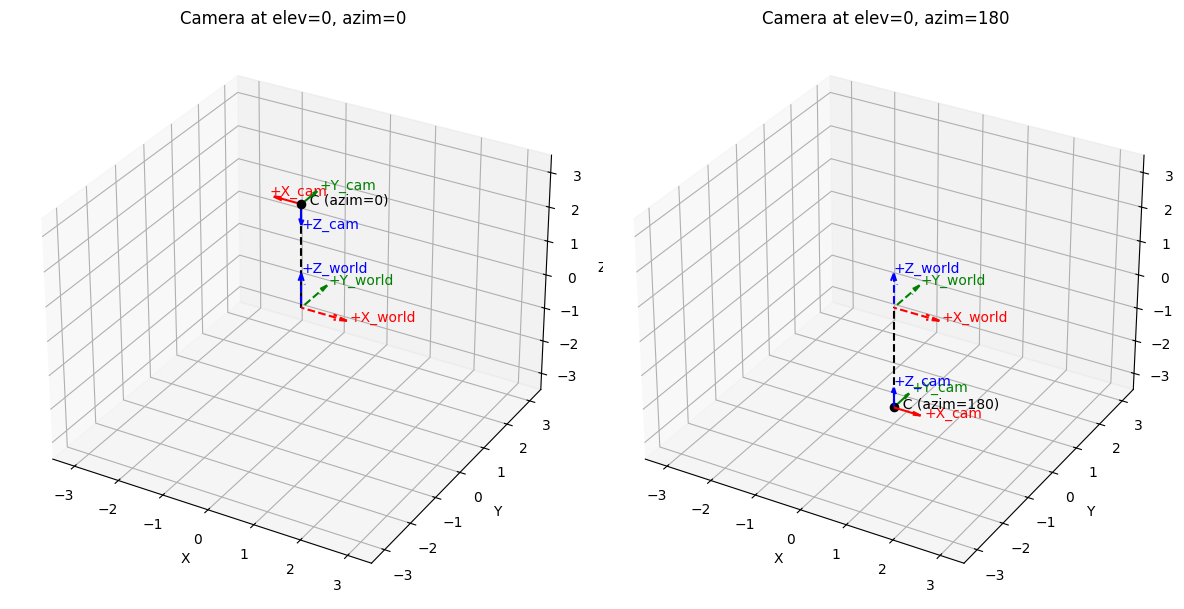

time: 607 ms (started: 2026-04-30 03:05:33 +00:00)


In [349]:
# --- Demo: azim = 0 vs 180 ---
device = torch.device("cpu")
dist, elev = 3.0, 0.0

fig = plt.figure(figsize=(12,6))
for i, azim in enumerate([0.0, 180.0]):
    R, T = look_at_view_transform(dist=dist, elev=elev, azim=azim, device=device)
    ax = fig.add_subplot(1,2,i+1, projection='3d')
    myp3dtools.plot_world_axes(ax, length=1.0)
    myp3dtools.plot_camera_axes_and_ray(R, T, ax, label=f"azim={azim:.0f}")

    # Nice bounds / labels
    s = dist + 0.5
    ax.set_xlim(-s, s); ax.set_ylim(-s, s); ax.set_zlim(-s, s)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title(f"Camera at elev=0, azim={azim:.0f}")

plt.tight_layout()
plt.show()


## **Example**: Azimuth (orbital) path plot of the PyTorch3D camera

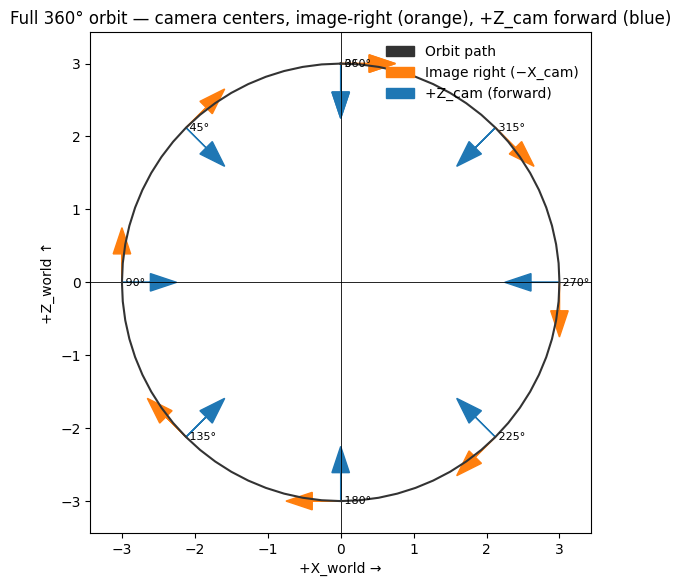

time: 231 ms (started: 2026-04-30 03:05:33 +00:00)


In [350]:

# Run it
myp3dtools.plot_orbit_with_cam_dirs(dist=3.0, elev=0.0, step_curve=5, step_arrows=45)


# Rendering textured meshes

## Load a mesh and texture file

Load an `.obj` file and its associated `.mtl` file and create a **Textures** and **Meshes** object.

**Meshes** is a unique datastructure provided in PyTorch3D for working with batches of meshes of different sizes.

**TexturesUV** is an auxiliary datastructure for storing vertex uv and texture maps for meshes.

**Meshes** has several class methods which are used throughout the rendering pipeline.

If running this notebook using **Google Colab**, run the following cell to fetch the mesh obj and texture files and save it at the path `data/cow_mesh`:
If running locally, the data is already available at the correct path.

### Download mesh files

In [351]:
# Example usage
myp3dtools.download_cow_mesh()

Creating data/cow_mesh directory...
cow.obj already exists, skipping.
cow.mtl already exists, skipping.
cow_texture.png already exists, skipping.
Cow mesh download complete!
time: 1.12 ms (started: 2026-04-30 03:05:34 +00:00)


### Load cad model into a Pytorch3D mesh

In [352]:
# Setup
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")

# Set paths
DATA_DIR = "./data"
obj_filename = os.path.join(DATA_DIR, "cow_mesh/cow.obj")

# Load obj file
mesh = load_objs_as_meshes([obj_filename], device=device)

time: 74.8 ms (started: 2026-04-30 03:05:34 +00:00)


### Let's visualize the texture map

PyTorch3D has a built-in way to view the texture map with matplotlib along with the points on the map corresponding to vertices. There is also a method, texturesuv_image_PIL, to get a similar image which can be saved to a file.

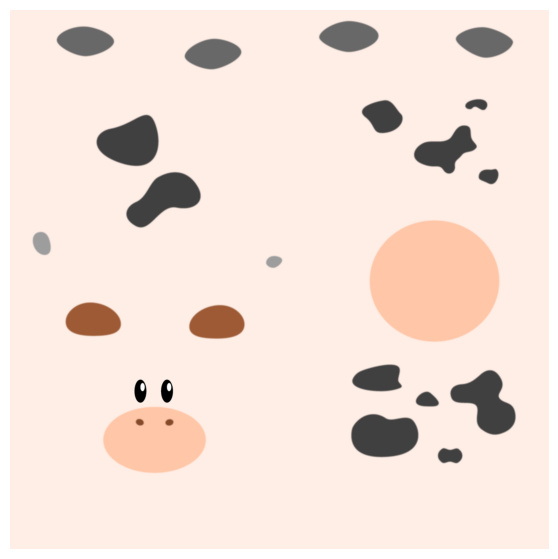

time: 166 ms (started: 2026-04-30 03:05:34 +00:00)


In [353]:
plt.figure(figsize=(7,7))
texture_image=mesh.textures.maps_padded()
plt.imshow(texture_image.squeeze().cpu().numpy())
plt.axis("off");

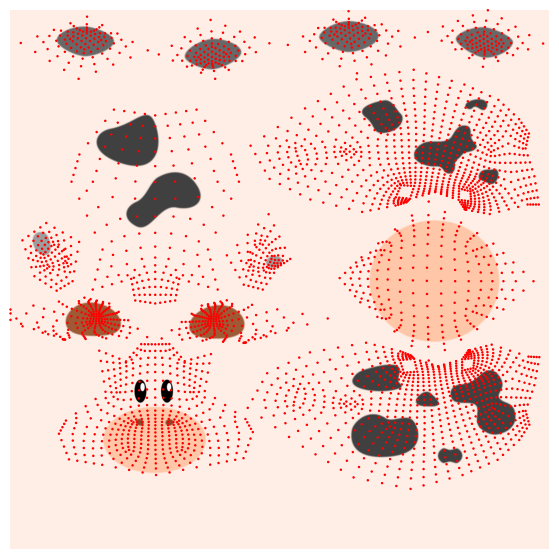

time: 32.5 s (started: 2026-04-30 03:05:34 +00:00)


In [354]:
plt.figure(figsize=(7,7))
texturesuv_image_matplotlib(mesh.textures, subsample=None)
plt.axis("off");

## Initialize the camera (and get your bearings)

* **Default view.** `look_at_view_transform(dist, elev=0, azim=0)` places the camera on the **+Z** axis at `(0, 0, dist)`, looking at the origin.
  The returned rotation is:

  $$
  R=\mathrm{diag}(-1,\;1,\;-1),
  $$

  which means (rows of $R$ = camera axes in world coords):

  * $+X_{\text{cam}}$ points along $-X_{\text{world}}$
  * $+Y_{\text{cam}}$ points along $+Y_{\text{world}}$
  * $+Z_{\text{cam}}$ points along $-Z_{\text{world}}$

  Practically: a small **+X\_world** step projects **to the right** in the image; **+Y\_world** projects **up** (note: image $v$ increases downward).

* **Opposite viewpoint.** To look from the other side (i.e., have the view direction along **+Z\_world**), set `azim=180` (with the same `elev=0`).
  This moves the camera to `(0, 0, -dist)` while still looking at the origin.

* **About the cow mesh.** The canonical PyTorch3D cow’s **front** faces **Z\_world**.

  * `azim=0` → rear view
  * `azim=180` → front view


> Tip: If you print `R` and take its **rows** as vectors, you’re reading the camera’s +X/+Y/+Z axes expressed in the **world** frame—handy for sanity checks.


## Create a renderer
Here, I am creating a general renderer (Soft Phong). We can later change its settings such as lights, camera.

### What requires a rebuild?

- Change **image size**, **faces_per_pixel**, **blur_radius**, **bin_size/max_faces_per_bin** → recreate rasterizer/renderer (or replace `renderer.rasterizer.raster_settings` with a new one).
- Change **shader type** or **blend params** → recreate/replace shader.

Everything else (new `R,T`, different intrinsics, per-frame light positions, materials) can be passed each call.


In [355]:
# Image size
W = 256
H = 256

# Create general (Soft) Phong renderer
phong_renderer = myp3dtools.make_phong_renderer(W, H, device)

time: 2.11 ms (started: 2026-04-30 03:06:06 +00:00)


## Camera position: Facing the front of the *cow*


══════════════════════════════════════
 🧭 Spherical camera pose  
                          
   dist = 3.000 
   elev = 0.000°    
   azim = 180.000°    
══════════════════════════════════════


📷 PyTorch3D Camera:

Camera Extrinsics (world→view, row-vector):
  R (1,3,3):
tensor([[[ 1.0000, -0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [-0.0000,  0.0000,  1.0000]]])
  T (1,3):  tensor([[-0., -0., 3.]])


+X_cam in world: tensor([ 1.0000,  0.0000, -0.0000])
+Y_cam in world: tensor([-0., 1., 0.])
+Z_cam in world: tensor([0.0000, 0.0000, 1.0000])


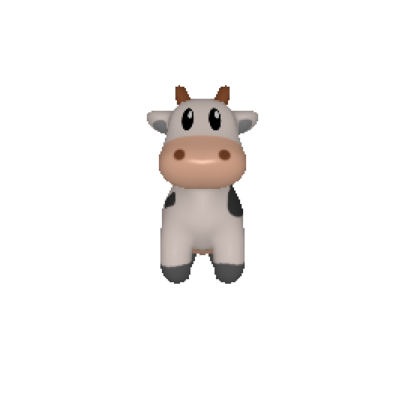

time: 90.4 ms (started: 2026-04-30 03:06:06 +00:00)


In [356]:
#          Camera pose in spherical coordinates
#==============================================================================
distance, elev, azim = 3, 0.0, 180.0   # front
#==============================================================================

# Pretty printing
myp3dtools.print_spherical_coords(distance, elev, azim)

# Get the camera pose (Row-major storage)
R, T = look_at_view_transform(distance, elev, azim)

# Pretty print camera information
myp3dtools.print_camera_pose_matrices(R, T, "PyTorch3D Camera")

# Create camera(s)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# Get camera center in world coordinates (handles batches)
light_loc = cameras.get_camera_center()          # shape: (N, 3)

# Create a Lights module at the camera center
lights = PointLights(device=device, location=cameras.get_camera_center())

# Set the renderer state as needed for the image(s)
myp3dtools.set_renderer_state(phong_renderer, cameras=cameras, lights=lights)

# Render images
images = phong_renderer(mesh)

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(images[0, ..., :3].cpu().numpy())
plt.axis("off");



## Camera position: Facing the back of the *cow*


══════════════════════════════════════
 🧭 Spherical camera pose  
                          
   dist = 3.000 
   elev = 0.000°    
   azim = 0.000°    
══════════════════════════════════════


📷 PyTorch3D Camera:

Camera Extrinsics (world→view, row-vector):
  R (1,3,3):
tensor([[[-1.,  0.,  0.],
         [ 0.,  1.,  0.],
         [ 0.,  0., -1.]]])
  T (1,3):  tensor([[-0., -0., 3.]])


+X_cam in world: tensor([-1.,  0.,  0.])
+Y_cam in world: tensor([0., 1., 0.])
+Z_cam in world: tensor([ 0.,  0., -1.])


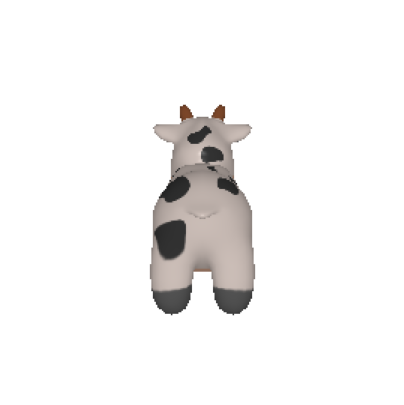

time: 76.3 ms (started: 2026-04-30 03:06:06 +00:00)


In [357]:
#          Camera pose in spherical coordinates
#==============================================================================
distance, elev, azim = 3, 0.0, 0.0   # front
#==============================================================================

# Pretty printing
myp3dtools.print_spherical_coords(distance, elev, azim)

# Get the camera pose (Row-major storage)
R, T = look_at_view_transform(distance, elev, azim)

# Pretty print camera information
myp3dtools.print_camera_pose_matrices(R, T, "PyTorch3D Camera")

# Create camera(s)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# Get camera center in world coordinates (handles batches)
light_loc = cameras.get_camera_center()          # shape: (N, 3)

# Create a Lights module at the camera center
lights = PointLights(device=device, location=cameras.get_camera_center())

# Set the renderer state as needed for the image(s)
myp3dtools.set_renderer_state(phong_renderer, cameras=cameras, lights=lights)

# Render images
images = phong_renderer(mesh)

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(images[0, ..., :3].cpu().numpy())
plt.axis("off");



## Rotate the object
Rotate the object by changing the elevation and azimuth angles



══════════════════════════════════════
 🧭 Spherical camera pose  
                          
   dist = 3.000 
   elev = 30.000°    
   azim = 170.000°    
══════════════════════════════════════


📷 PyTorch3D Camera:

Camera Extrinsics (world→view, row-vector):
  R (1,3,3):
tensor([[[ 0.9848, -0.0868, -0.1504],
         [-0.0000,  0.8660, -0.5000],
         [ 0.1736,  0.4924,  0.8529]]])
  T (1,3):  tensor([[0.0000, -0.0000, 3.0000]])


+X_cam in world: tensor([0.9848, -0.0000, 0.1736])
+Y_cam in world: tensor([-0.0868,  0.8660,  0.4924])
+Z_cam in world: tensor([-0.1504, -0.5000,  0.8529])


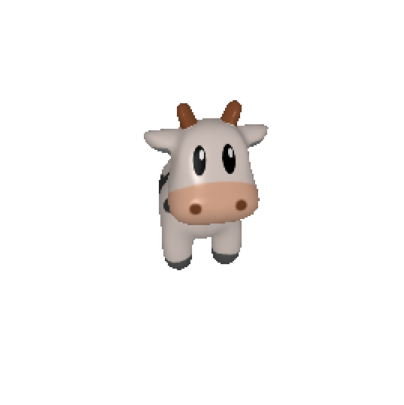

time: 76.4 ms (started: 2026-04-30 03:06:07 +00:00)


In [358]:

#          Camera pose in spherical coordinates
#==============================================================================
distance, elev, azim = 3, 30.0, 170.0   # front
#==============================================================================

# Pretty printing
myp3dtools.print_spherical_coords(distance, elev, azim)

# Get the camera pose (Row-major storage)
R, T = look_at_view_transform(distance, elev, azim)

# Pretty print camera information
myp3dtools.print_camera_pose_matrices(R, T, "PyTorch3D Camera")

# Create camera(s)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# Get camera center in world coordinates (handles batches)
light_loc = cameras.get_camera_center()          # shape: (N, 3)

# Create a Lights module at the camera center
lights = PointLights(device=device, location=cameras.get_camera_center())

# Set the renderer state as needed for the image(s)
myp3dtools.set_renderer_state(phong_renderer, cameras=cameras, lights=lights)

# Render images
images = phong_renderer(mesh)

rgb_rotated = images[0, ..., :3].cpu().numpy()

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(rgb_rotated)
plt.axis("off");


## Show coordinate system
Here, we plot the world coordinate system (PyTorch3D)

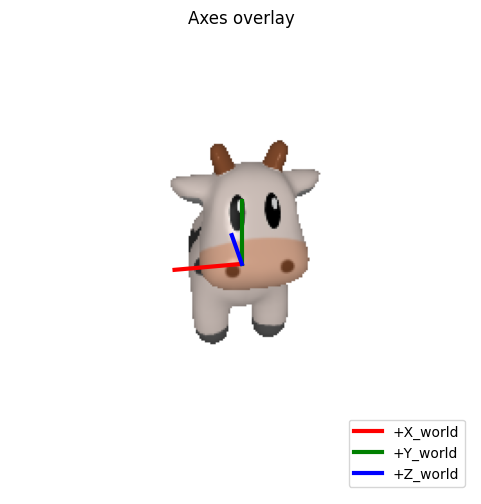

time: 110 ms (started: 2026-04-30 03:06:07 +00:00)


In [359]:
myp3dtools.overlay_axes_p3d(rgb_rotated, cameras, 256, 256,
                 world_origin=(0,0,0), axis_len=0.5,
                 draw_world_axes=True, draw_camera_axes=False,
                 cam_axis_len=0.5,
                 title="Axes overlay")

###  Overlay quadrant sample points (PyTorch3D)

In [360]:
# ---- Config: sample points around the world origin on the z=0 plane ----------
L = 0.25  # distance from origin (world units)
samples_world = np.array([
    [ +L, +L, 0.0],  # (+,+)
    [ -L, +L, 0.0],  # (-,+)
    [ -L, -L, 0.0],  # (-,-)
    [ +L, -L, 0.0],  # (+,-)
    [  0,   0, 0.0], # origin
], dtype=np.float32)



time: 832 µs (started: 2026-04-30 03:06:07 +00:00)


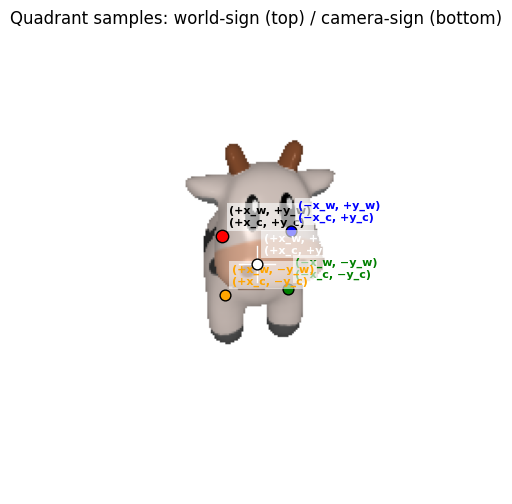

Index | World (x,y,z)         | Camera (x,y,z)         | Pixel (u,v)
    0 |  +0.250  +0.250  +0.000 |  +0.224  +0.217  +3.167 |  108.76  112.78
    1 |  -0.250  +0.250  +0.000 |  -0.268  +0.217  +3.080 |  146.74  109.87
    2 |  -0.250  -0.250  +0.000 |  -0.224  -0.217  +2.833 |  145.26  141.66
    3 |  +0.250  -0.250  +0.000 |  +0.268  -0.217  +2.920 |  110.32  145.11
    4 |  +0.000  +0.000  +0.000 |  +0.000  +0.000  +3.000 |  128.00  128.00
time: 153 ms (started: 2026-04-30 03:06:07 +00:00)


In [361]:
# === Overlay quadrant sample points (PyTorch3D) ===============================
import torch, numpy as np, matplotlib.pyplot as plt

# ---- Project to screen --------------------------------------------------------
device = cameras.R.device
dtype  = cameras.R.dtype
imgsz  = torch.tensor([[H, W]], device=device)

Xw = torch.from_numpy(samples_world).to(device=device, dtype=dtype)[None]  # (1,N,3)

# Pixel projection (v increases downward)
uvz = cameras.transform_points_screen(Xw, image_size=imgsz)[0]  # (N,3)
uv  = uvz[:, :2].detach().cpu().numpy()

# Also compute camera coords to show sign mapping
R = cameras.R[0]            # (3,3)
T = cameras.T[0]            # (3,)
Xc = (Xw[0] @ R.T) + T      # (N,3) row-vector convention

# ---- Draw --------------------------------------------------------------------
plt.figure(figsize=(6,6))
plt.imshow(rgb_rotated)
plt.axis("off")

for i, (pt_w, (u,v), pt_c) in enumerate(zip(samples_world, uv, Xc.detach().cpu().numpy())):
    xw, yw, zw = pt_w
    xc, yc, zc = pt_c
    col = myp3dtools.color_for(xw, yw)
    m   = myp3dtools.marker_for(xw, yw)

    # scatter the point
    plt.scatter([u], [v], s=60 if i>0 else 80, c=col, marker=m, edgecolors='k' if i>0 else 'k', linewidths=1.0, zorder=3)

    # label with world sign and (optional) camera sign
    label = f"({myp3dtools.sign2(xw)}x_w, {myp3dtools.sign2(yw)}y_w)\n({myp3dtools.sign2(xc)}x_c, {myp3dtools.sign2(yc)}y_c)"
    # offset text a bit so labels don't overlap markers
    plt.text(u+4, v-6, label, color=col if i>0 else "black",
             fontsize=8, weight="bold", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2))

# Crosshair at principal point (for reference)
cx = float(cameras.principal_point[0,0]) if hasattr(cameras, "principal_point") else W/2
cy = float(cameras.principal_point[0,1]) if hasattr(cameras, "principal_point") else H/2
plt.plot([cx-10, cx+10], [cy, cy], color="white", lw=1)
plt.plot([cx, cx], [cy-10, cy+10], color="white", lw=1)
plt.title("Quadrant samples: world-sign (top) / camera-sign (bottom)")
plt.show()

# ---- Console summary ----------------------------------------------------------
print("Index | World (x,y,z)         | Camera (x,y,z)         | Pixel (u,v)")
for i, (pt_w, pt_c, (u,v)) in enumerate(zip(samples_world, Xc.detach().cpu().numpy(), uv)):
    print(f"{i:5d} | {pt_w[0]:+7.3f} {pt_w[1]:+7.3f} {pt_w[2]:+7.3f} | "
          f"{pt_c[0]:+7.3f} {pt_c[1]:+7.3f} {pt_c[2]:+7.3f} | "
          f"{u:7.2f} {v:7.2f}")


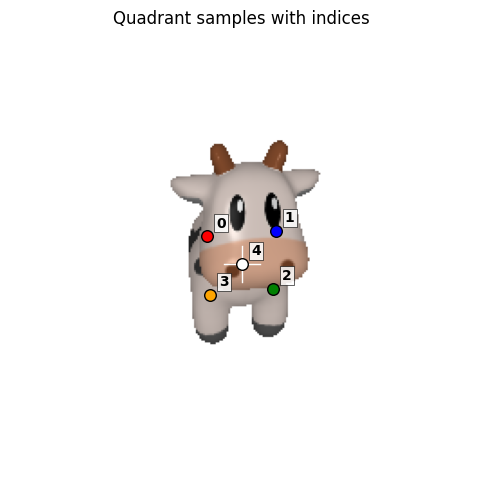

Index | World (x,y,z)         | Camera (x,y,z)         | Pixel (u,v)
    0 |  +0.250  +0.250  +0.000 |  +0.224  +0.217  +3.167 |  108.76  112.78
    1 |  -0.250  +0.250  +0.000 |  -0.268  +0.217  +3.080 |  146.74  109.87
    2 |  -0.250  -0.250  +0.000 |  -0.224  -0.217  +2.833 |  145.26  141.66
    3 |  +0.250  -0.250  +0.000 |  +0.268  -0.217  +2.920 |  110.32  145.11
    4 |  +0.000  +0.000  +0.000 |  +0.000  +0.000  +3.000 |  128.00  128.00
time: 132 ms (started: 2026-04-30 03:06:07 +00:00)


In [362]:
# === Overlay quadrant sample points with indices ==============================
import torch, numpy as np, matplotlib.pyplot as plt

# ---- Project to screen --------------------------------------------------------
device = cameras.R.device
dtype  = cameras.R.dtype
imgsz  = torch.tensor([[H, W]], device=device)

Xw = torch.from_numpy(samples_world).to(device=device, dtype=dtype)[None]  # (1,N,3)
uvz = cameras.transform_points_screen(Xw, image_size=imgsz)[0]             # (N,3)
uv  = uvz[:, :2].detach().cpu().numpy()

# Camera-frame coordinates (row-vector convention)
R = cameras.R[0]; T = cameras.T[0]
Xc = (Xw[0] @ R.T) + T    # (N,3)

# ---- Draw --------------------------------------------------------------------
plt.figure(figsize=(6,6))
plt.imshow(rgb_rotated)


plt.axis("off")

for i, (pt_w, (u,v), pt_c) in enumerate(zip(samples_world, uv, Xc.detach().cpu().numpy())):
    xw, yw, zw = pt_w
    xc, yc, zc = pt_c
    col = myp3dtools.color_for(xw, yw)

    # scatter the point
    plt.scatter([u], [v], s=70, c=col, marker="o", edgecolors="k", linewidths=1.0, zorder=3)

    # index label next to the dot
    plt.text(u+5, v-5, f"{i}", fontsize=10, weight="bold",
             bbox=dict(facecolor="white", alpha=0.85, edgecolor="black", linewidth=0.5, pad=1.5))

# Crosshair at principal point (for reference)
cx = float(cameras.principal_point[0,0]) if hasattr(cameras, "principal_point") else W/2
cy = float(cameras.principal_point[0,1]) if hasattr(cameras, "principal_point") else H/2
plt.plot([cx-10, cx+10], [cy, cy], color="white", lw=1)
plt.plot([cx, cx], [cy-10, cy+10], color="white", lw=1)
plt.title("Quadrant samples with indices")
plt.show()

# ---- Console summary (indexed) -----------------------------------------------
print("Index | World (x,y,z)         | Camera (x,y,z)         | Pixel (u,v)")
for i, (pt_w, pt_c, (u,v)) in enumerate(zip(samples_world, Xc.detach().cpu().numpy(), uv)):
    print(f"{i:5d} | {pt_w[0]:+7.3f} {pt_w[1]:+7.3f} {pt_w[2]:+7.3f} | "
          f"{pt_c[0]:+7.3f} {pt_c[1]:+7.3f} {pt_c[2]:+7.3f} | "
          f"{u:7.2f} {v:7.2f}")


# Rendering images using PyTorch3D and OpenCV camera poses (R,T)



## Example 1:
This example shows how to render an image using a PyTorch3D  camera created from an OpenCV camera intrinsics using `PerspectiveCamera()`. The same view is also rendered using a simple projection function that uses opencv coordinate system. The conversion from Pytorch3D (R_p3d, t_p3d) to OpenCV (R_cv, t_cv) is handled by the PyTorch3D helper function `opencv_from_cameras_projection()`.

### Perspective PyTorch3D camera from K and R,T in PyTorch3D coordinate system

In [363]:
# Define camera and image settings using intrinsics in pixels (OpenCV-style)
H, W = 256, 256
image_size = torch.tensor([[H, W]], dtype=torch.float32, device=device)
fx = fy = 200.0
cx, cy = W/2, H/2

time: 1.25 ms (started: 2026-04-30 03:06:07 +00:00)



══════════════════════════════════════
 🧭 Spherical camera pose  
                          
   dist = 3.000 
   elev = 10.000°    
   azim = 180.000°    
══════════════════════════════════════


📷 *** PyTorch3D Camera ***:

Camera Extrinsics (world→view, row-vector):
  R (1,3,3):
tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  0.9848, -0.1736],
         [-0.0000,  0.1736,  0.9848]]], device='cuda:0')
  T (1,3):  tensor([[-0.0000, -0.0000, 3.0000]], device='cuda:0')


+X_cam in world: tensor([ 1.0000,  0.0000, -0.0000], device='cuda:0')
+Y_cam in world: tensor([0.0000, 0.9848, 0.1736], device='cuda:0')
+Z_cam in world: tensor([ 0.0000, -0.1736,  0.9848], device='cuda:0')


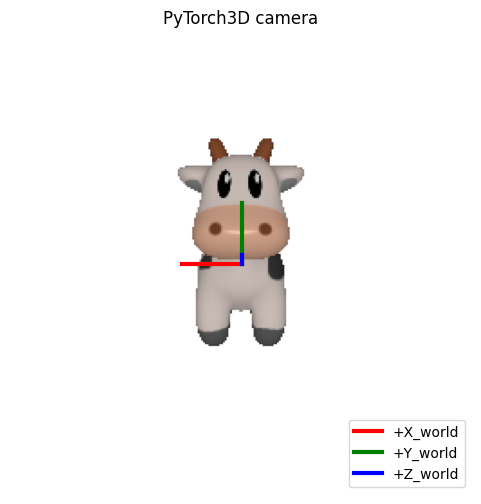

time: 124 ms (started: 2026-04-30 03:06:07 +00:00)


In [364]:
import torch
from pytorch3d.renderer import PerspectiveCameras
from pytorch3d.utils import opencv_from_cameras_projection, cameras_from_opencv_projection

# --- PyTorch3D + OpenCV: render the same pose using an EXISTING mesh ----------
# Requirements: `mesh` is a PyTorch3D Meshes with a single item (batch=1).
# If it has no textures, a flat vertex color is applied for PyTorch3D shading.

import numpy as np
import torch, cv2
import matplotlib.pyplot as plt

from pytorch3d.renderer import (
    MeshRenderer, MeshRasterizer, SoftPhongShader, RasterizationSettings,
    PointLights, PerspectiveCameras, Materials
)
from pytorch3d.structures import Meshes
from pytorch3d.renderer import TexturesVertex


#------------------------------------------------------------------------------
# Pose in PyTorch3D (world -> view)
dist=3
elev=10
azim=180
R_p3d, T_p3d = look_at_view_transform(dist=dist, elev=elev, azim=azim, device=device)

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ----------------------------- Assume existing mesh ---------------------------
# `mesh` must exist: a PyTorch3D Meshes (batch=1). Example:
# assert isinstance(mesh, Meshes), "`mesh` must be a PyTorch3D Meshes."


# -- PyTorch3D camera -------------------------------
cams = PerspectiveCameras(
    focal_length=((fx, fy),),
    principal_point=((cx, cy),),
    image_size=((H, W),),
    R=R_p3d, T=T_p3d,
    in_ndc=False,
    device=device
)

# Pretty printing
myp3dtools.print_spherical_coords(distance, elev, azim)

# Pretty print camera information
myp3dtools.print_camera_pose_matrices(R_p3d, T_p3d, "*** PyTorch3D Camera ***")

# Get camera center in world coordinates (handles batches)
light_loc = cams.get_camera_center()          # shape: (N, 3)

# Create a Lights module at the camera center
lights = PointLights(device=device, location=cams.get_camera_center())

# Set the renderer state as needed for the image(s)
myp3dtools.set_renderer_state(phong_renderer, cameras=cams, lights=lights)

# Render images
images = phong_renderer(mesh)

# Make tensor into rgb
p3d_img = images[0, ..., :3].cpu().numpy()


# -- Show results ---------------------------------
myp3dtools.overlay_axes_p3d(p3d_img, cams, 256, 256,
                 world_origin=(0,0,0), axis_len=0.5,
                 draw_world_axes=True, draw_camera_axes=False,
                 cam_axis_len=0.5,
                 title="PyTorch3D camera")

### Using PyTorch3D helper function (R_p3d, T_p3d) to (R_cv,T_cv) -> OpenCV rendering

In [365]:
# Image size as torch tensor
image_size=torch.tensor([[H, W]], dtype=torch.float32, device=device)

# Get R, T in OpenCV coordinates (as torch tensors) - PyTorch3D helper
R_cv, t_cv, _ = opencv_from_cameras_projection(cams, image_size)

# Pretty print camera information
myp3dtools.print_camera_pose_matrices(R_cv, t_cv, "*** OpenCV Camera ***")

# Print transpose of tensor rotation matrix
light_loc = myp3dtools.camera_center_from_RT_openCV(R_cv, t_cv)
print(f"\nCamera center (OpenCV): {light_loc}\n")


📷 *** OpenCV Camera ***:

Camera Extrinsics (world→view, row-vector):
  R (1,3,3):
tensor([[[-1.0000, -0.0000,  0.0000],
         [-0.0000, -0.9848, -0.1736],
         [ 0.0000, -0.1736,  0.9848]]], device='cuda:0')
  T (1,3):  tensor([[0.0000, 0.0000, 3.0000]], device='cuda:0')


+X_cam in world: tensor([-1.0000, -0.0000,  0.0000], device='cuda:0')
+Y_cam in world: tensor([-0.0000, -0.9848, -0.1736], device='cuda:0')
+Z_cam in world: tensor([ 0.0000, -0.1736,  0.9848], device='cuda:0')

Camera center (OpenCV): [-0.      0.5209 -2.9544]

time: 11.7 ms (started: 2026-04-30 03:06:07 +00:00)


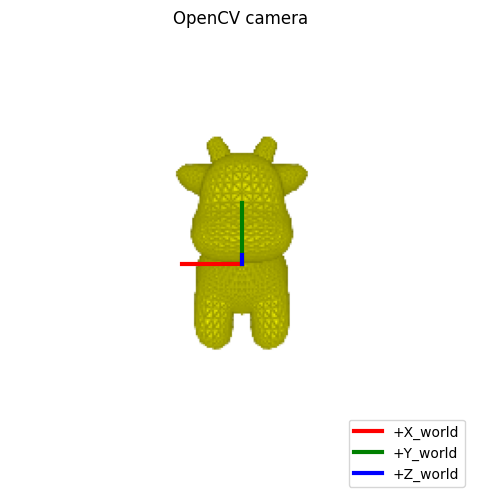

time: 202 ms (started: 2026-04-30 03:06:07 +00:00)


In [366]:
# Build K and OpenCV extrinsics corresponding to the same physical pose
# The conversion pytorch3d-to-opencv needs K as a tensor
# Helper cameras_from_opencv_projection expects K as a tensor
K = torch.tensor([[[fx, 0., cx],
                   [0., fy, cy],
                   [0.,  0., 1.]]], device=device)

# Convert K to numpy (simple matrix)
K_cv = K.squeeze().cpu().numpy()

# Render image of the mesh using opencv lines, polygons
img_cv_rgb = myp3dtools.render_image_with_opencv_lines_opencv_coordinates(mesh, R_cv, t_cv, K_cv, W, H)


#------------------------------- Show results ---------------------------------
myp3dtools.overlay_axes_p3d(img_cv_rgb, cams, 256, 256,
                 world_origin=(0,0,0), axis_len=0.5,
                 draw_world_axes=True, draw_camera_axes=False,
                 cam_axis_len=0.5,
                 title="OpenCV camera")


## Example 2:  
Rendering in PyTorch3D from a camera created from OpenCV `(R_cv, t_cv)` using the PyTorch3D helper function `cameras_from_opencv_projection()`.


🎯 Building PerspectiveCameras from OpenCV (K, R_cv, t_cv)
📸 PyTorch3D camera created from OpenCV intrinsics passed to helper function
K (OpenCV):
tensor([[[200.,   0., 128.],
         [  0., 200., 128.],
         [  0.,   0.,   1.]]], device='cuda:0')
image_size: tensor([[256., 256.]], device='cuda:0')
focal_length (pixels): tensor([[1.5625, 1.5625]], device='cuda:0')
principal_point (pixels): tensor([[-0., -0.]], device='cuda:0')

📷 *** PyTorch3D Camera ***:

Camera Extrinsics (world→view, row-vector):
  R (1,3,3):
tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  0.9848, -0.1736],
         [-0.0000,  0.1736,  0.9848]]], device='cuda:0')
  T (1,3):  tensor([[-0.0000, -0.0000, 3.0000]], device='cuda:0')


+X_cam in world: tensor([ 1.0000,  0.0000, -0.0000], device='cuda:0')
+Y_cam in world: tensor([0.0000, 0.9848, 0.1736], device='cuda:0')
+Z_cam in world: tensor([ 0.0000, -0.1736,  0.9848], device='cuda:0')


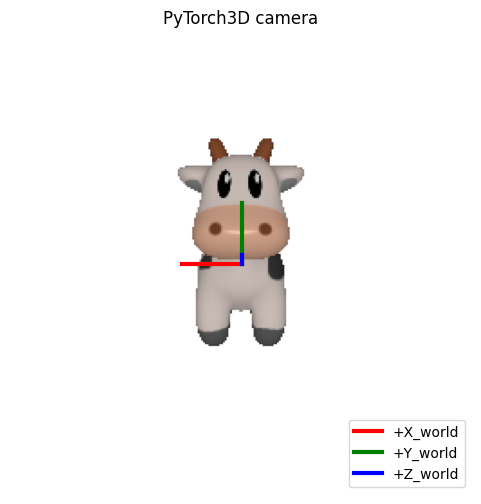

time: 129 ms (started: 2026-04-30 03:06:07 +00:00)


In [367]:

# ---------- Build camera from OpenCV K,R,t ----------
say("step", "\n🎯 Building PerspectiveCameras from OpenCV (K, R_cv, t_cv)")
# image_size is (N,2) tensor or list-like (H,W); device must match your setup
cameras_new = cameras_from_opencv_projection(
    R=R_cv, tvec=t_cv, camera_matrix=K, image_size=image_size)

say("ok", "📸 PyTorch3D camera created from OpenCV intrinsics passed to helper function")
print(f"{BOLD}K (OpenCV):{RESET}\n{K}")
print(f"{BOLD}image_size:{RESET} {cameras_new.image_size}")
print(f"{BOLD}focal_length (pixels):{RESET} {cameras_new.focal_length}")
print(f"{BOLD}principal_point (pixels):{RESET} {cameras_new.principal_point}")


# Pretty print camera pose information
myp3dtools.print_camera_pose_matrices(cameras_new.R, cameras_new.T, "*** PyTorch3D Camera ***")

# Get camera center in world coordinates (handles batches)
light_loc = cameras_new.get_camera_center()          # shape: (N, 3)

# Create a Lights module at the camera center
lights = PointLights(device=device, location=cameras_new.get_camera_center())

# Set the renderer state as needed for the image(s)
myp3dtools.set_renderer_state(phong_renderer, cameras=cameras_new, lights=lights)

# Render images
images = phong_renderer(mesh)

rgb_p3d = images[0, ..., :3].cpu().numpy()




# ------------------------------- Show results ---------------------------------
myp3dtools.overlay_axes_p3d(rgb_p3d, cameras_new, 256, 256,
                 world_origin=(0,0,0), axis_len=0.5,
                 draw_world_axes=True, draw_camera_axes=False,
                 cam_axis_len=0.5,
                 title="PyTorch3D camera")



## Example 3:  Depth map

In [368]:
def depth_to_rgb(
    depth: torch.Tensor,
    cmap: str = "viridis",
    bg_mode: Literal["black","white","transparent"] = "black"
) -> np.ndarray:
    """
    Convert a PyTorch3D depth map into a visualization image.
    Automatically treats depth = -1 as invalid background.

    Args:
        depth: (H,W) torch.Tensor of depth values (float).
        cmap:  Matplotlib colormap name (default: "viridis").
        bg_mode:
            "black"       -> background stays black (default)
            "white"       -> background set to white
            "transparent" -> return RGBA image with alpha=0 for background

    Returns:
        img: (H,W,3) uint8 RGB or (H,W,4) uint8 RGBA if bg_mode="transparent"
    """
    if not isinstance(depth, torch.Tensor):
        raise ValueError("depth must be a torch.Tensor")

    depth_np = depth.detach().cpu().numpy().astype(np.float32)

    # Mask out invalid regions (zbuf = -1 means background in PyTorch3D)
    valid_mask = depth_np > 0

    if np.any(valid_mask):
        dmin, dmax = depth_np[valid_mask].min(), depth_np[valid_mask].max()
        depth_norm = np.zeros_like(depth_np, dtype=np.float32)
        depth_norm[valid_mask] = (depth_np[valid_mask] - dmin) / (dmax - dmin + 1e-8)
    else:
        depth_norm = np.zeros_like(depth_np, dtype=np.float32)

    cmap_func = cm.get_cmap(cmap)
    rgba = cmap_func(depth_norm)  # (H,W,4) floats in [0,1]

    if bg_mode == "transparent":
        rgba[..., 3] = 0.0          # alpha=0 where background
        rgba[valid_mask, 3] = 1.0   # alpha=1 where valid
        img = (rgba * 255).astype(np.uint8)  # RGBA
    else:
        rgb = (rgba[..., :3] * 255).astype(np.uint8)
        if bg_mode == "white":
            rgb[~valid_mask] = [255,255,255]
        elif bg_mode == "black":
            rgb[~valid_mask] = [0,0,0]
        img = rgb

    return img


time: 2.73 ms (started: 2026-04-30 03:06:08 +00:00)


/tmp/ipykernel_15309/320872188.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_func = cm.get_cmap(cmap)


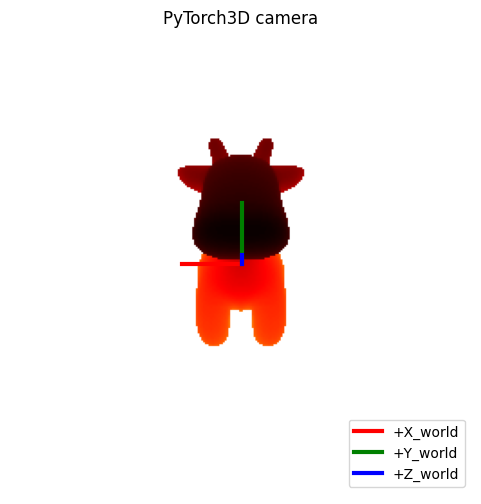

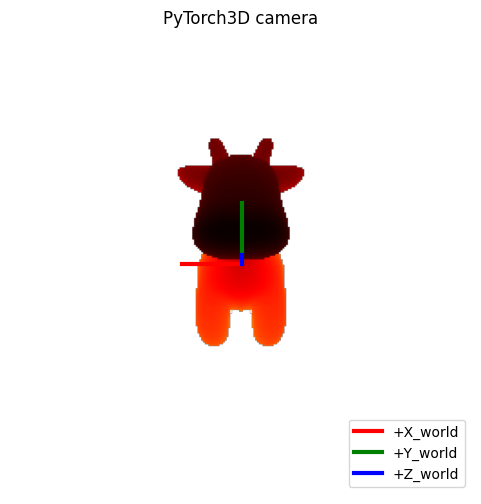

time: 355 ms (started: 2026-04-30 03:06:08 +00:00)


In [369]:
fragments = phong_renderer.rasterizer(mesh)
depth_map = fragments.zbuf[0, ..., 0].detach()                     # (H,W) torch.float32

# Depth visualization (treat -1 as invalid)
vis1 = depth_to_rgb(depth_map, cmap="hot", bg_mode="white")

# ------------------------------- Show results ---------------------------------
myp3dtools.overlay_axes_p3d(vis1, cameras_new, 256, 256,
                 world_origin=(0,0,0), axis_len=0.5,
                 draw_world_axes=True, draw_camera_axes=False,
                 cam_axis_len=0.5,
                 title="PyTorch3D camera")


# Depth visualization (treat -1 as invalid)
vis2_rgba = depth_to_rgb(depth_map, cmap="hot", bg_mode="transparent")

# ------------------------------- Show results ---------------------------------
myp3dtools.overlay_axes_p3d(vis2_rgba, cameras_new, 256, 256,
                 world_origin=(0,0,0), axis_len=0.5,
                 draw_world_axes=True, draw_camera_axes=False,
                 cam_axis_len=0.5,
                 title="PyTorch3D camera")


# Batched Rendering

One of the core design choices of the PyTorch3D API is to support **batched inputs for all components**.
The renderer and associated components can take batched inputs and **render a batch of output images in one forward pass**. We will now use this feature to render the mesh from many different viewpoints.


## Create a renderer

A renderer in PyTorch3D is composed of a **rasterizer** and a **shader** which each have a number of subcomponents such as a **camera** (orthographic/perspective). Here we initialize some of these components and use default values for the rest.

In this example we will first create a **renderer** which uses a **perspective camera**, a **point light** and applies **Phong shading**. Then we learn how to vary different components using the modular API.  

In [370]:
# Initialize a camera.
# With world coordinates +Y up, +X left and +Z in, the front of the cow is facing the -Z direction.
# So we move the camera by 180 in the azimuth direction so it is facing the front of the cow.
# R, T = look_at_view_transform(2.7, 0, 180)
# cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# Define the settings for rasterization and shading. Here we set the output image to be of size
# 512x512. As we are rendering images for visualization purposes only we will set faces_per_pixel=1
# and blur_radius=0.0. We also set bin_size and max_faces_per_bin to None which ensure that
# the faster coarse-to-fine rasterization method is used. Refer to rasterize_meshes.py for
# explanations of these parameters. Refer to docs/notes/renderer.md for an explanation of
# the difference between naive and coarse-to-fine rasterization.
raster_settings = RasterizationSettings(
    image_size=256,
    blur_radius=0.0,
    faces_per_pixel=1,
)

# Place a point light in front of the object. As mentioned above, the front of the cow is facing the
# -z direction.
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# Create a Phong renderer by composing a rasterizer and a shader. The textured Phong shader will
# interpolate the texture uv coordinates for each vertex, sample from a texture image and
# apply the Phong lighting model
renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=cameras,
    )
)

time: 4.82 ms (started: 2026-04-30 03:06:08 +00:00)


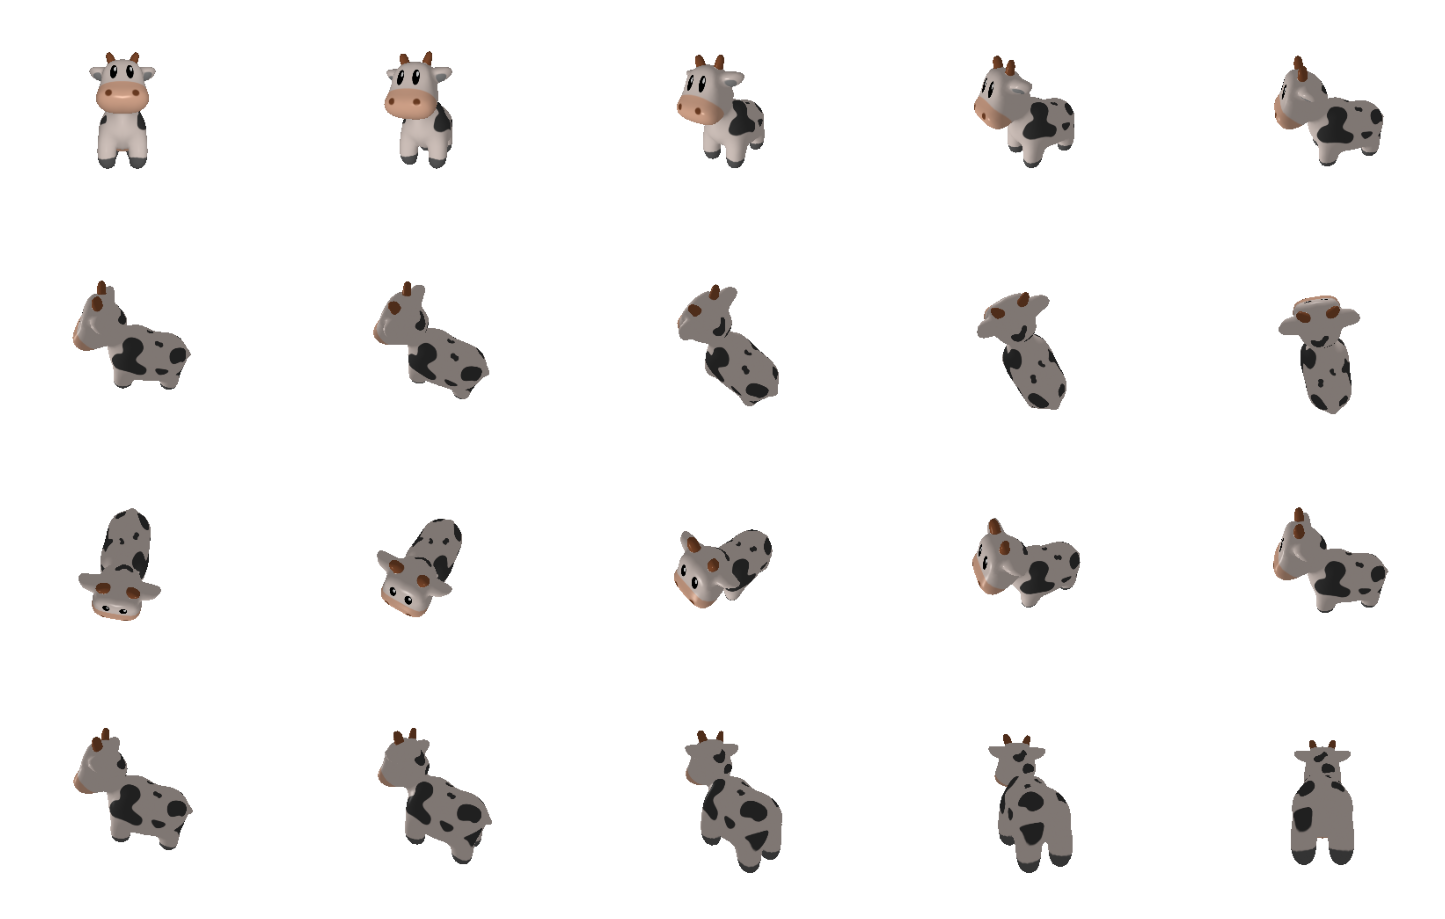

time: 754 ms (started: 2026-04-30 03:06:08 +00:00)


In [371]:
# Set batch size - this is the number of different viewpoints from which we want to render the mesh.
batch_size = 20

# Create a batch of meshes by repeating the cow mesh and associated textures.
# Meshes has a useful `extend` method which allows us do this very easily.
# This also extends the textures.
meshes = mesh.extend(batch_size)

# Get a batch of viewing angles.
elev = torch.linspace(0, 180, batch_size)
azim = torch.linspace(-180, 180, batch_size)

# All the cameras helper methods support mixed type inputs and broadcasting. So we can
# view the camera from the same distance and specify dist=2.7 as a float,
# and then specify elevation and azimuth angles for each viewpoint as tensors.
R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
cameras = PerspectiveCameras(
    focal_length=((fx, fy),),
    principal_point=((cx, cy),),
    image_size=((H, W),),
    R=R, T=T,
    in_ndc=False,
    device=device
)

# Move the light back in front of the cow which is facing the -z direction.
lights.location = torch.tensor([[0.0, 0.0, -3.0]], device=device)

# We can pass arbitrary keyword arguments to the rasterizer/shader via the renderer
# so the renderer does not need to be reinitialized if any of the settings change.
images = renderer(meshes, cameras=cameras, lights=lights)

# Show images as a grid
image_grid(images.cpu().numpy(), rows=4, cols=5, rgb=True)

## Creating a Dataset of Rendered Outputs

We will now collect the rendered RGB images, their corresponding silhouettes, depth maps, and camera parameters for each viewpoint generated during batched rendering into a structured dataset. This allows for easier access and further processing of the generated data.

Successfully collected a dataset of 20 samples.
First sample keys: dict_keys(['rgb_image', 'silhouette_mask', 'depth_map', 'camera_R', 'camera_T', 'camera_K', 'camera_focal_length', 'camera_principal_point'])


/tmp/ipykernel_15309/320872188.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_func = cm.get_cmap(cmap)


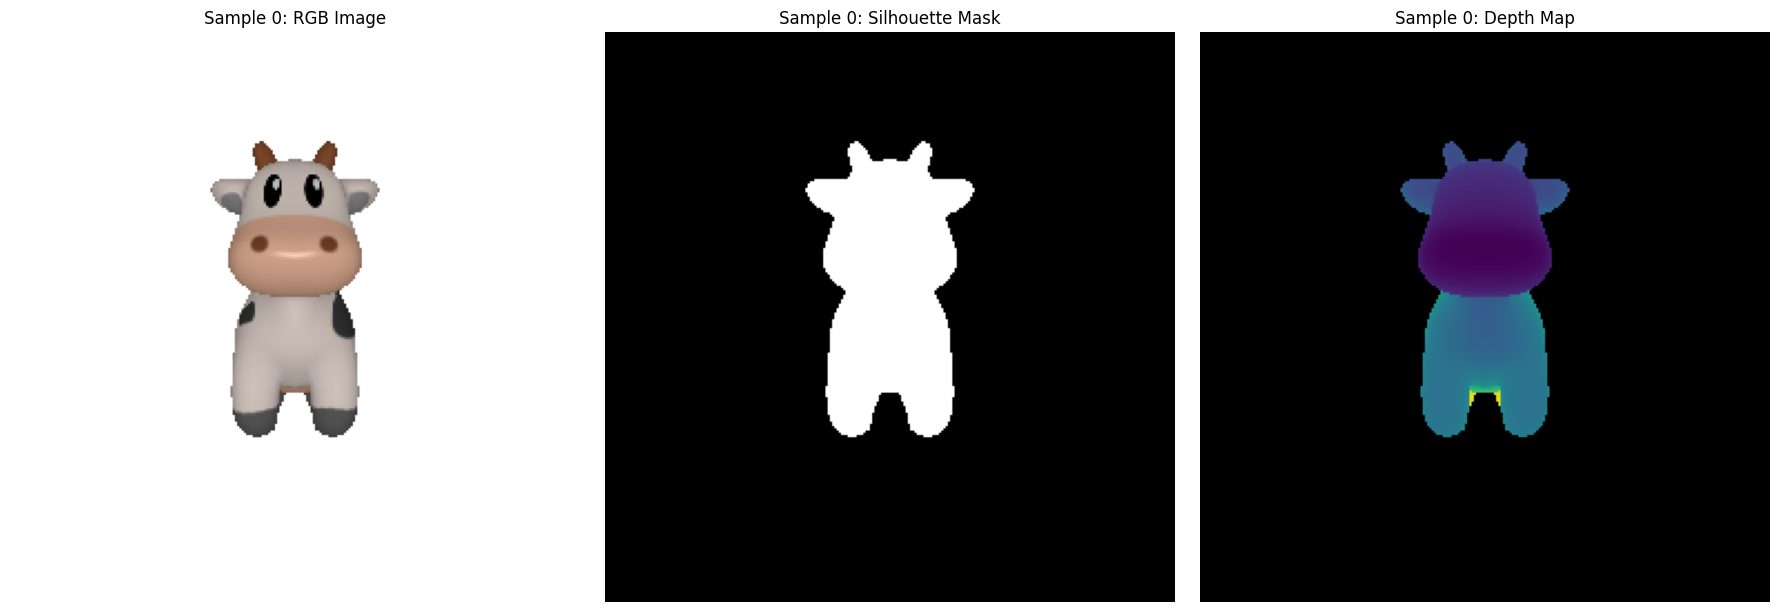

time: 1.94 s (started: 2026-04-30 03:06:09 +00:00)


In [372]:
# Re-render with the 'renderer' object to get both images and fragments (for depth)
# Note: The 'images' from the previous cell are only RGB. We need fragments for depth.
# The 'renderer' object from cell AzocnGpcUdjD is already configured for batched rendering.

# Ensure device is defined (can be global or local to a function)
import torch

if 'device' not in locals():
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Ensure raster_settings, lights, and renderer are defined if not already
# (Copying from AzocnGpcUdjD)
if 'raster_settings' not in locals():
    from pytorch3d.renderer import RasterizationSettings, PointLights, MeshRenderer, MeshRasterizer, SoftPhongShader
    raster_settings = RasterizationSettings(
        image_size=256,
        blur_radius=0.0,
        faces_per_pixel=1,
    )

if 'lights' not in locals():
    lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# 'cameras' is expected to be defined from cell CDQKebNNfBMI, which precedes this
if 'renderer' not in locals() and 'cameras' in locals():
    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(
            raster_settings=raster_settings
        ),
        shader=SoftPhongShader(
            device=device,
            cameras=cameras,
        )
    )

# To get fragments, we use the rasterizer component of the renderer directly.
batched_fragments = renderer.rasterizer(meshes_world=meshes, cameras=cameras)

collected_dataset = []

for i in range(batch_size):
    # Extract RGB image for the current view
    rgb_image = images[i, ..., :3].cpu().numpy() # 'images' comes from the previous cell

    # Extract depth map for the current view
    # fragments.zbuf has shape (N, H, W, K) where K is faces_per_pixel. We take the first face.
    depth_map_i = batched_fragments.zbuf[i, ..., 0].detach()

    # Generate silhouette (binary mask) for the current view
    # Convert RGB to 0-255 uint8 for the contour function
    rgb_image_uint8 = (rgb_image * 255).astype(np.uint8)
    _, mask_i, _ = myimgtools.ImageProcessor.contour_from_nonwhite_rgb(
        rgb_image_uint8, draw_color=(255, 0, 0), return_masks=True
    )

    # Extract camera extrinsics (R, T) for the current view
    R_i = cameras.R[i].cpu().numpy()
    T_i = cameras.T[i].cpu().numpy()

    # Extract camera intrinsics (focal length and principal point)
    # Assuming focal_length and principal_point are either single values for the batch or batched
    focal_length_i = cameras.focal_length[0].cpu().numpy() if cameras.focal_length.ndim == 2 else cameras.focal_length[i].cpu().numpy()
    principal_point_i = cameras.principal_point[0].cpu().numpy() if cameras.principal_point.ndim == 2 else cameras.principal_point[i].cpu().numpy()

    # Construct K matrix (simplified, assuming no skew and principal point is (cx,cy) for image origin (0,0))
    K_i = np.array([
        [focal_length_i[0], 0, principal_point_i[0]],
        [0, focal_length_i[1], principal_point_i[1]],
        [0, 0, 1]
    ], dtype=np.float32)

    # Store all collected data for the current view in a dictionary
    collected_data = {
        "rgb_image": rgb_image,
        "silhouette_mask": mask_i,
        "depth_map": depth_map_i,
        "camera_R": R_i,
        "camera_T": T_i,
        "camera_K": K_i,
        "camera_focal_length": focal_length_i,
        "camera_principal_point": principal_point_i
    }
    collected_dataset.append(collected_data)

print(f"Successfully collected a dataset of {len(collected_dataset)} samples.")
print(f"First sample keys: {collected_dataset[0].keys()}")

# Display the RGB image, silhouette, and depth map for the first sample to verify
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(collected_dataset[0]["rgb_image"])
axes[0].set_title("Sample 0: RGB Image")
axes[0].axis("off")

axes[1].imshow(collected_dataset[0]["silhouette_mask"], cmap="gray")
axes[1].set_title("Sample 0: Silhouette Mask")
axes[1].axis("off")

# For depth visualization, use the helper function 'depth_to_rgb' defined previously
depth_vis = depth_to_rgb(collected_dataset[0]["depth_map"], cmap="viridis", bg_mode="black")
axes[2].imshow(depth_vis)
axes[2].set_title("Sample 0: Depth Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Save the Dataset to Disk

Now we will save the collected data (RGB images, silhouette masks, depth maps, and camera parameters) to persistent storage. Each image type will be saved as a PNG file, and all associated metadata and image paths will be stored in a single CSV file.

In [373]:
import pandas as pd
import imageio.v2 as imageio
import os
import numpy as np # Ensure numpy is imported

# Ensure DATA_DIR is defined
if 'DATA_DIR' not in locals():
    DATA_DIR = "./data"

# Define output directories
output_base_dir = os.path.join(DATA_DIR, "rendered_dataset")
os.makedirs(output_base_dir, exist_ok=True)

rgb_dir = os.path.join(output_base_dir, "rgb_images")
os.makedirs(rgb_dir, exist_ok=True)

silhouette_dir = os.path.join(output_base_dir, "silhouette_masks")
os.makedirs(silhouette_dir, exist_ok=True)

depth_dir = os.path.join(output_base_dir, "depth_maps")
os.makedirs(depth_dir, exist_ok=True)

# Prepare data for CSV
csv_data = []

print(f"Saving {len(collected_dataset)} samples to: {output_base_dir}/")

for i, sample in enumerate(collected_dataset):
    # Define filenames
    base_name = f"sample_{i:04d}"
    rgb_path = os.path.join(rgb_dir, f"{base_name}_rgb.png")
    silhouette_path = os.path.join(silhouette_dir, f"{base_name}_silhouette.png")
    depth_path = os.path.join(depth_dir, f"{base_name}_depth.png")

    # Add paths to the sample dictionary itself for later access
    sample["rgb_image_path"] = rgb_path
    sample["silhouette_mask_path"] = silhouette_path
    sample["depth_map_path"] = depth_path

    # Save RGB image (convert from float [0,1] to uint8 [0,255])
    imageio.imwrite(rgb_path, (sample["rgb_image"] * 255).astype(np.uint8))

    # Save Silhouette mask
    imageio.imwrite(silhouette_path, sample["silhouette_mask"])

    # Save Depth map (convert to a suitable format for saving as image, e.g., colormapped or normalized)
    # Using the depth_to_rgb helper for visualization here
    depth_vis_rgb = depth_to_rgb(sample["depth_map"], cmap="viridis", bg_mode="black")
    imageio.imwrite(depth_path, depth_vis_rgb)

    # Collect data for CSV
    row = {
        "sample_id": i,
        "rgb_image_path": rgb_path,
        "silhouette_mask_path": silhouette_path,
        "depth_map_path": depth_path,
        "camera_R": str(sample["camera_R"]).replace('\n', ' '),
        "camera_T": str(sample["camera_T"]).replace('\n', ' '),
        "camera_K": str(sample["camera_K"]).replace('\n', ' '),
        "camera_focal_length_x": sample["camera_focal_length"][0],
        "camera_focal_length_y": sample["camera_focal_length"][1],
        "camera_principal_point_x": sample["camera_principal_point"][0],
        "camera_principal_point_y": sample["camera_principal_point"][1]
    }
    csv_data.append(row)

# Create and save DataFrame to CSV
df_dataset = pd.DataFrame(csv_data)
csv_output_path = os.path.join(output_base_dir, "dataset_metadata.csv")
df_dataset.to_csv(csv_output_path, index=False)

print(f"Dataset saved successfully. Metadata available at: {csv_output_path}")
print("First 5 rows of the metadata CSV:")
display(df_dataset.head())

# Optionally, display paths for a sample
print(f"\nExample paths for Sample 0:")
print(f"  RGB: {collected_dataset[0]['rgb_image_path']}")
print(f"  Silhouette: {collected_dataset[0]['silhouette_mask_path']}")
print(f"  Depth: {collected_dataset[0]['depth_map_path']}")

Saving 20 samples to: ./data/rendered_dataset/


/tmp/ipykernel_15309/320872188.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_func = cm.get_cmap(cmap)


Dataset saved successfully. Metadata available at: ./data/rendered_dataset/dataset_metadata.csv
First 5 rows of the metadata CSV:


,sample_id,rgb_image_path,silhouette_mask_path,depth_map_path,camera_R,camera_T,camera_K,camera_focal_length_x,camera_focal_length_y,camera_principal_point_x,camera_principal_point_y
0,0,./data/rendered_dataset/rgb_images/sample_0000...,./data/rendered_dataset/silhouette_masks/sampl...,./data/rendered_dataset/depth_maps/sample_0000...,[[ 1. 0. -0.] [-0. 1. 0.] [ 0. 0. 1.]],[-0. -0. 2.7],[[200. 0. 128.] [ 0. 200. 128.] [ 0. 0...,200.0,200.0,128.0,128.0
1,1,./data/rendered_dataset/rgb_images/sample_0001...,./data/rendered_dataset/silhouette_masks/sampl...,./data/rendered_dataset/depth_maps/sample_0001...,[[ 0.9458 0.0534 0.3203] [ 0. 0.9864 -...,[-0. 0. 2.7],[[200. 0. 128.] [ 0. 200. 128.] [ 0. 0...,200.0,200.0,128.0,128.0
2,2,./data/rendered_dataset/rgb_images/sample_0002...,./data/rendered_dataset/silhouette_masks/sampl...,./data/rendered_dataset/depth_maps/sample_0002...,[[ 0.7891 0.1994 0.5809] [ 0. 0.9458 -...,[-0. -0. 2.7],[[200. 0. 128.] [ 0. 200. 128.] [ 0. 0...,200.0,200.0,128.0,128.0
3,3,./data/rendered_dataset/rgb_images/sample_0003...,./data/rendered_dataset/silhouette_masks/sampl...,./data/rendered_dataset/depth_maps/sample_0003...,[[ 0.5469 0.3984 0.7363] [ 0. 0.8795 -...,[-0. -0. 2.7],[[200. 0. 128.] [ 0. 200. 128.] [ 0. 0...,200.0,200.0,128.0,128.0
4,4,./data/rendered_dataset/rgb_images/sample_0004...,./data/rendered_dataset/silhouette_masks/sampl...,./data/rendered_dataset/depth_maps/sample_0004...,[[ 0.2455 0.5954 0.765 ] [ 0. 0.7891 -...,[-0. 0. 2.7],[[200. 0. 128.] [ 0. 200. 128.] [ 0. 0...,200.0,200.0,128.0,128.0



Example paths for Sample 0:
  RGB: ./data/rendered_dataset/rgb_images/sample_0000_rgb.png
  Silhouette: ./data/rendered_dataset/silhouette_masks/sample_0000_silhouette.png
  Depth: ./data/rendered_dataset/depth_maps/sample_0000_depth.png
time: 1.03 s (started: 2026-04-30 03:06:11 +00:00)


# Creating masks, transparent images, contours, and blending images

### Another function that displays a wireframe

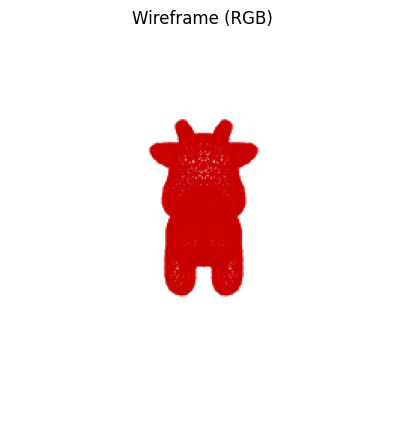

time: 1.19 s (started: 2026-04-30 03:06:12 +00:00)


In [374]:
import matplotlib.pyplot as plt
from pytorch3d.io import load_objs_as_meshes
from pytorch3d.renderer.cameras import PerspectiveCameras

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

wireframe_image = myimgtools.ImageProcessor.mesh_wireframe_image(
    mesh, cameras_new, (H, W),
    edge_mode="all", feature_deg=60.0,
    line_rgb=(200, 0, 0), line_thickness=1
)

plt.figure(figsize=(7,5))
plt.imshow(wireframe_image); plt.axis("off"); plt.title("Wireframe (RGB)")
plt.show()


### Creating masks and contours

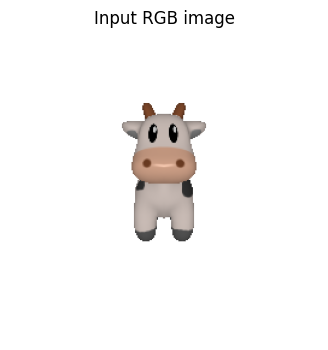

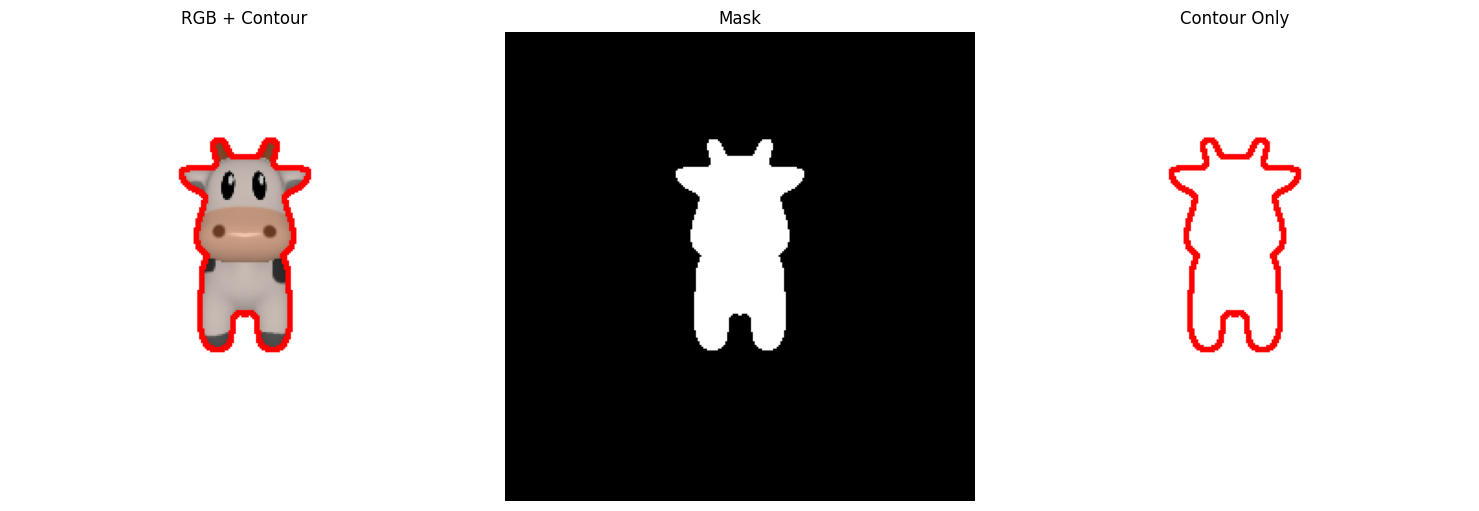

time: 1.08 s (started: 2026-04-30 03:06:13 +00:00)


In [375]:
# Create some useful images to superimpose on the reference image during matching
contour_img, mask, contour_only = myimgtools.ImageProcessor.contour_from_nonwhite_rgb(
    rgb_p3d, draw_color=(255, 0, 0), return_masks = True)

plt.figure(figsize=(4,4))
plt.imshow(rgb_p3d); plt.axis("off"); plt.title("Input RGB image")
plt.show()


# Create a single row with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# First image
axes[0].imshow(contour_img)
axes[0].axis("off")
axes[0].set_title("RGB + Contour")

# Second image
axes[1].imshow(mask, cmap="gray")
axes[1].axis("off")
axes[1].set_title("Mask")

# Third image
axes[2].imshow(contour_only)
axes[2].axis("off")
axes[2].set_title("Contour Only")

plt.tight_layout()
plt.show()


### Depth map display: white background and transparent (alpha)

Here, the background can be either white or transparent. The object region is not transparent.

/tmp/ipykernel_15309/320872188.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_func = cm.get_cmap(cmap)


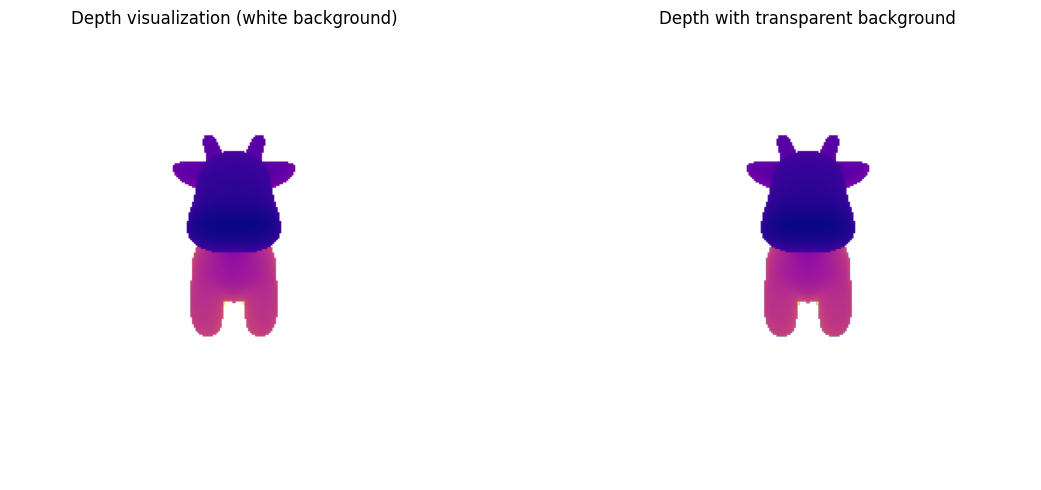

time: 702 ms (started: 2026-04-30 03:06:14 +00:00)


In [376]:

# depth is a (H,W) torch tensor from PyTorch3D fragments.zbuf
depth_rgb_white_bg = depth_to_rgb(depth_map, cmap="plasma", bg_mode="white")
depth_rgba_transparent_bg = depth_to_rgb(depth_map, cmap="plasma", bg_mode="transparent")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Depth with white background
axes[0].imshow(depth_rgb_white_bg)
axes[0].axis("off")
axes[0].set_title("Depth visualization (white background)")

# Depth with transparent background
axes[1].imshow(depth_rgba_transparent_bg)
axes[1].axis("off")
axes[1].set_title("Depth with transparent background")

plt.tight_layout()
plt.show()

### Display semi-transparent overlay
In this visualization, the object region is transparent but not the contour line. The line remains opaque. This visualization is good to show alignment.

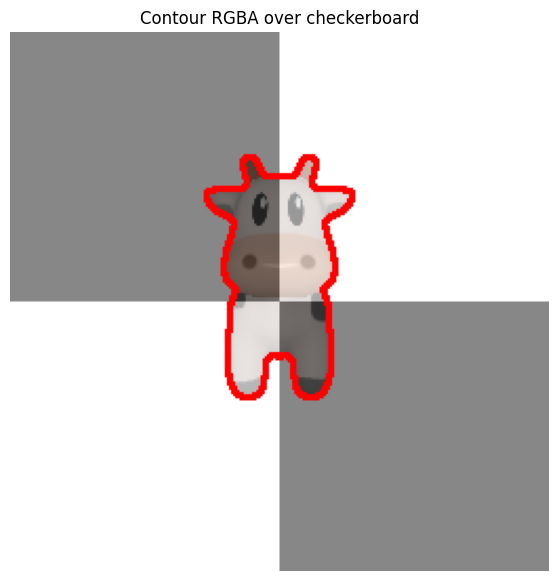

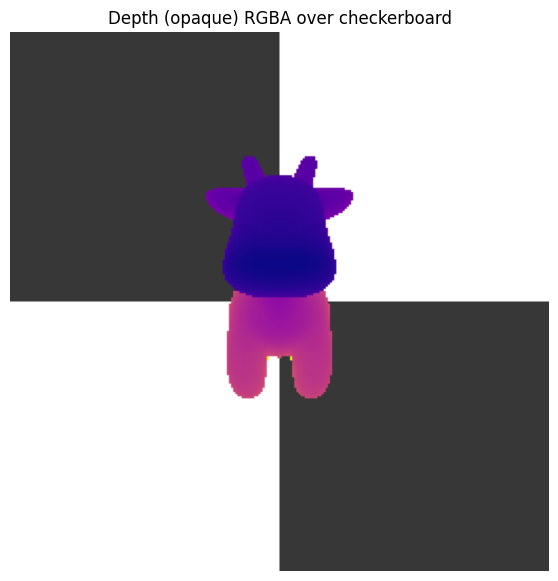

time: 646 ms (started: 2026-04-30 03:06:15 +00:00)


In [377]:
import matplotlib.pyplot as plt
import numpy as np

# Assume you already have your RGBA result
contour_rgba = myimgtools.ImageProcessor.contour_from_nonwhite_rgb_semi_transparent(
    rgb_p3d,
    draw_color=(255,0,0),
    thickness=2,
    return_rgba=True,
    alpha_value=0.4
)

# --- Create a checkerboard background ---
def checkerboard_2x2(h, w):
    """Generate a 2x2 checkerboard (4 squares) background."""
    cb = np.zeros((h, w), dtype=np.uint8)

    # Define light and dark gray
    colors = [55, 255]  # dark gray, light gray

    # Fill quadrants
    half_h, half_w = h // 2, w // 2
    cb[:half_h, :half_w] = colors[0]  # top-left
    cb[:half_h, half_w:] = colors[1]  # top-right
    cb[half_h:, :half_w] = colors[1]  # bottom-left
    cb[half_h:, half_w:] = colors[0]  # bottom-right

    # Make it RGB
    cb_rgb = np.dstack([cb]*3)
    return cb_rgb


H, W = contour_rgba.shape[:2]
background = checkerboard_2x2(H, W)


# --- Blend RGBA over the background ---
alpha = contour_rgba[...,3:4] / 255.0   # (H,W,1)
overlay = (alpha * contour_rgba[...,:3] + (1-alpha)*background).astype(np.uint8)

# --- Show ---
plt.figure(figsize=(7,7))
plt.imshow(overlay)
plt.axis("off")
plt.title("Contour RGBA over checkerboard")
plt.show()



# --- Blend RGBA over the background ---
alpha = depth_rgba_transparent_bg[...,3:4] / 255.0   # (H,W,1)
overlay = (alpha * depth_rgba_transparent_bg[...,:3] + (1-alpha)*background).astype(np.uint8)

# --- Show ---
plt.figure(figsize=(7,7))
plt.imshow(overlay)
plt.axis("off")
plt.title("Depth (opaque) RGBA over checkerboard")
plt.show()


### Show semitransparent alpha overlay on depth map

Here, the transparent rgb is overlayed on the depth image creating a composition of depth map and rgb, with the semi-transparent object pixels.

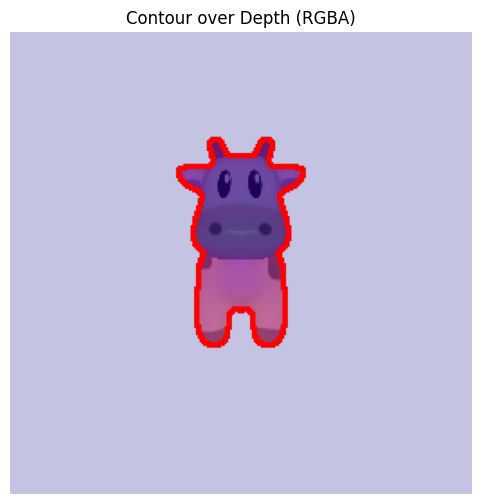

time: 239 ms (started: 2026-04-30 03:06:15 +00:00)


In [378]:
# depth_rgba: RGBA from your depth visualization (bg_mode="transparent")
# contour_rgba: RGBA from contour function (object semi-transparent, contour opaque)

composited = myimgtools.ImageProcessor.alpha_over_rgba(depth_rgba_transparent_bg, contour_rgba, resize_overlay=True)
# Show with matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(composited)
plt.axis("off")
plt.title("Contour over Depth (RGBA)")
plt.show()


### Visualizing reference image and test image as overlay
This example shows the overlay of the depth+rgb with the reference image.

In [379]:
# Create a new alpha channel with a solid value (e.g., 255 for full opacity)
alpha_channel = np.full((256, 256), fill_value=0, dtype=np.uint8)

# Use dstack to stack the alpha channel onto the existing RGB image
rgba_image1 = np.dstack((p3d_img, alpha_channel))

# Use dstack to stack the alpha channel onto the existing RGB image
rgba_image2 = np.dstack((rgb_rotated, alpha_channel))



time: 17.9 ms (started: 2026-04-30 03:06:16 +00:00)


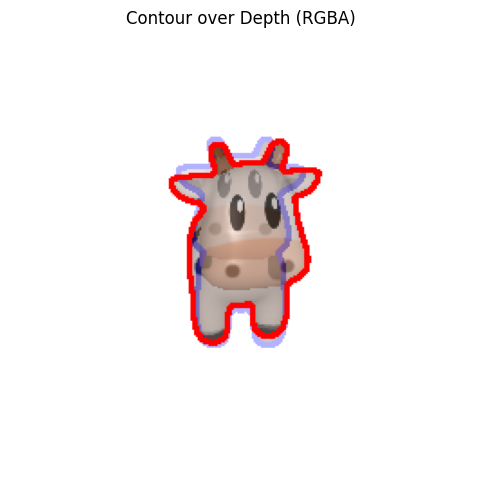

time: 481 ms (started: 2026-04-30 03:06:16 +00:00)


In [380]:

# Assume you already have your RGBA result
contour_img_ref = myimgtools.ImageProcessor.contour_from_nonwhite_rgb_semi_transparent(
    rgb_p3d,
    draw_color=(0,0,255),
    thickness=2,
    return_rgba=True,
    alpha_value=0.99
)



# Assume you already have your RGBA result
contour_rgba = myimgtools.ImageProcessor.contour_from_nonwhite_rgb_semi_transparent(
    rgb_rotated,
    draw_color=(255,0,0),
    thickness=2,
    return_rgba=True,
    alpha_value=0.7
)



# depth is a (H,W) torch tensor from PyTorch3D fragments.zbuf
# depth_rgba2 = unproject_tools.ImageProcessor.depth_to_rgb(depth_ref, cmap="gray", bg_mode="transparent")

composited2 = myimgtools.ImageProcessor.alpha_over_rgba(contour_img_ref, contour_rgba, resize_overlay=True)
# Show with matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(composited2)
plt.axis("off")
plt.title("Contour over Depth (RGBA)")
plt.show()



Projection function 'project_3d_to_2d_with_visibility' defined.

Projected 2930 visible vertices.
First 5 projected pixel coordinates:
 tensor([[0.1906, 0.0000],
        [0.1288, 0.0000],
        [0.1322, 0.0781],
        [0.0937, 0.0000],
        [0.1611, 0.0000]], device='cuda:0')


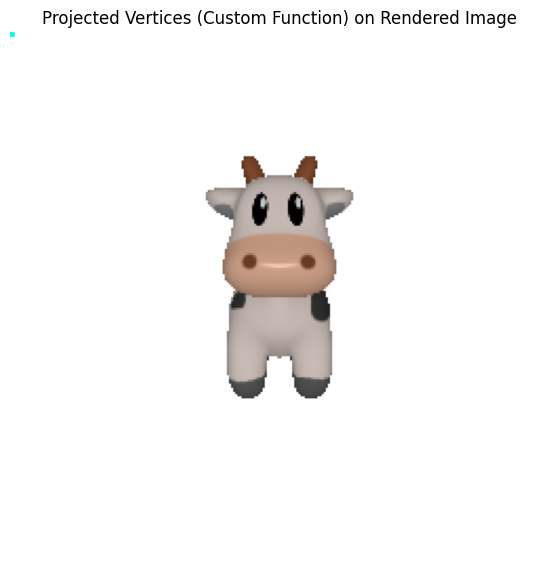

time: 354 ms (started: 2026-04-30 03:06:16 +00:00)


In [381]:
import torch
import numpy as np

def project_3d_to_2d_with_visibility(X_world, K, R, T, image_size):
    """
    Projects 3D world coordinates to 2D pixel coordinates using camera intrinsics and extrinsics.
    Handles homogeneous normalization and visibility (z > 0).

    Args:
        X_world (torch.Tensor or np.ndarray): (N, 3) tensor/array of 3D world coordinates.
        K (torch.Tensor or np.ndarray): (3, 3) camera intrinsic matrix.
        R (torch.Tensor or np.ndarray): (3, 3) camera rotation matrix (world to camera).
        T (torch.Tensor or np.ndarray): (3,) camera translation vector (world to camera).
        image_size (tuple or list): (H, W) tuple representing the image dimensions.

    Returns:
        tuple: A tuple containing:
            - pixel_coords (torch.Tensor): (N_visible, 2) tensor of 2D pixel coordinates (u, v).
            - visible_mask (torch.Tensor): (N,) boolean mask indicating visible points.
            - X_camera_visible (torch.Tensor): (N_visible, 3) camera coordinates for visible points.
    """
    # Ensure 'device' is available globally or passed as an argument
    global device # Assuming 'device' is defined in the global scope (e.g., 'cuda:0' or 'cpu')

    if isinstance(X_world, np.ndarray):
        X_world = torch.from_numpy(X_world).float().to(device)
    if isinstance(K, np.ndarray):
        K = torch.from_numpy(K).float().to(device)
    if isinstance(R, np.ndarray):
        R = torch.from_numpy(R).float().to(device)
    if isinstance(T, np.ndarray):
        T = torch.from_numpy(T).float().to(device)

    # Ensure all tensors are on the same device after potential conversions
    if X_world.device != device: X_world = X_world.to(device)
    if K.device != device: K = K.to(device)
    if R.device != device: R = R.to(device)
    if T.device != device: T = T.to(device)

    if X_world.ndim == 2 and X_world.shape[1] == 3:
        # Add a batch dimension if missing for R, T, K
        if R.ndim == 2: R = R.unsqueeze(0) # (1, 3, 3)
        if T.ndim == 1: T = T.unsqueeze(0) # (1, 3)
        if K.ndim == 2: K = K.unsqueeze(0) # (1, 3, 3)

        # Transform world coordinates to camera coordinates: X_camera = (X_world @ R_T) + T
        # X_world is (N, 3), R is (1, 3, 3), T is (1, 3)
        # R.transpose(-1, -2) is (1, 3, 3)
        # (X_world @ R.transpose(-1, -2)) results in (1, N, 3) after broadcasting X_world
        # T.unsqueeze(1) is (1, 1, 3)
        # Summing gives (1, N, 3)
        X_camera = (X_world @ R.transpose(-1, -2)) + T.unsqueeze(1)
        X_camera = X_camera.squeeze(0) # Remove batch dimension to get (N, 3)

        # Check for visibility: z > 0
        visible_mask = X_camera[:, 2] > 0
        X_camera_visible = X_camera[visible_mask]

        if X_camera_visible.shape[0] == 0:
            # print("No visible points.") # Commented out to avoid spamming for every voxel
            return torch.empty(0, 2, device=device), visible_mask, torch.empty(0, 3, device=device)

        # Project camera coordinates to image plane (homogeneous): x_img_hom = K @ X_camera_visible_T
        # K is (1, 3, 3)
        # X_camera_visible is (N_visible, 3)
        # X_camera_visible.transpose(1, 0).unsqueeze(0) gives (1, 3, N_visible)
        x_image_hom_T = K @ X_camera_visible.transpose(1, 0).unsqueeze(0) # Result is (1, 3, N_visible)
        x_image_hom = x_image_hom_T.squeeze(0).transpose(1, 0) # Result is (N_visible, 3)

        # Perform homogeneous normalization: (u, v) = (x_img / z_img, y_img / z_img)
        # Add a small epsilon to z to avoid division by zero for points exactly on the camera plane.
        pixel_coords = x_image_hom[:, :2] / (x_image_hom[:, 2:] + 1e-8)

        # Clamp pixel coordinates to image boundaries (optional, but good practice)
        H, W = image_size
        pixel_coords[:, 0].clamp_(0, W - 1)
        pixel_coords[:, 1].clamp_(0, H - 1)

        return pixel_coords, visible_mask, X_camera_visible
    else:
        raise ValueError("X_world must be an (N, 3) tensor or numpy array.")


print("Projection function 'project_3d_to_2d_with_visibility' defined.")


# --- Example Usage (using existing variables from the notebook) ---

# Assuming `mesh`, `cameras_new`, `H`, `W` are already defined from previous cells
# Use the `cameras_new` object which is a PyTorch3D camera created from OpenCV K,R,t

# Get the R and T matrices from the cameras_new object
R_p3d_from_opencv = cameras_new.R.squeeze(0) # (3,3)
T_p3d_from_opencv = cameras_new.T.squeeze(0) # (3,)

# Get the K matrix (intrinsic) from the cameras_new object
# PyTorch3D stores focal length and principal point, so reconstruct K
fx = cameras_new.focal_length[0, 0]
fy = cameras_new.focal_length[0, 1]
cx = cameras_new.principal_point[0, 0]
cy = cameras_new.principal_point[0, 1]
K_p3d_reconstructed = torch.tensor(
    [[fx, 0., cx],
     [0., fy, cy],
     [0., 0., 1.]],
    device=device, dtype=torch.float32)

# Get the mesh vertices in world coordinates
verts_world = mesh.verts_padded()[0] # (N_verts, 3)

# Project the vertices using the custom function
pixel_coords_custom, visible_mask_custom, X_camera_visible_custom = \
    project_3d_to_2d_with_visibility(verts_world, K_p3d_reconstructed, R_p3d_from_opencv, T_p3d_from_opencv, (H, W))

print(f"\nProjected {pixel_coords_custom.shape[0]} visible vertices.")
print("First 5 projected pixel coordinates:\n", pixel_coords_custom[:5])

# Visualize the projected points on the original image (rgb_p3d should be available)
plt.figure(figsize=(7,7))
plt.imshow(rgb_p3d)
plt.scatter(pixel_coords_custom[:, 0].cpu().numpy(), pixel_coords_custom[:, 1].cpu().numpy(), s=5, c='cyan', alpha=0.7)
plt.title("Projected Vertices (Custom Function) on Rendered Image")
plt.axis("off")
plt.show()

## 📦 Voxel Carving based on Silhouette Consistency

This section implements a basic voxel carving algorithm. It involves:

1.  **Defining a 3D voxel grid** that encloses the object.
2.  **Iterating through each voxel** in the grid.
3.  For each voxel, **projecting it into every camera view** from the `collected_dataset`.
4.  **Checking if the projected voxel lies inside the object's silhouette** for that view.
5.  **Removing voxels** that are inconsistent with *any* silhouette (i.e., they project outside the silhouette in at least one view).

This process iteratively refines the 3D representation of the object.

In [382]:
# 1. Define a 3D voxel grid enclosing the object

# Get the bounding box of the mesh
verts_world = mesh.verts_padded()[0] # Shape (N_verts, 3)
x_min, y_min, z_min = verts_world.min(dim=0).values.cpu().numpy()
x_max, y_max, z_max = verts_world.max(dim=0).values.cpu().numpy()

# Expand bounding box slightly for robustness
padding = 0.1
x_min -= padding; y_min -= padding; z_min -= padding
x_max += padding; y_max += padding; z_max += padding

# Define voxel resolution
num_voxels_per_dim = 100 # Adjust for desired resolution
x_coords = torch.linspace(x_min, x_max, num_voxels_per_dim, device=device)
y_coords = torch.linspace(y_min, y_max, num_voxels_per_dim, device=device)
z_coords = torch.linspace(z_min, z_max, num_voxels_per_dim, device=device)

# Create a 3D grid of voxel centers
x_grid, y_grid, z_grid = torch.meshgrid(x_coords, y_coords, z_coords, indexing='ij')
voxel_grid_3d = torch.stack([x_grid, y_grid, z_grid], dim=-1) # (D, D, D, 3)

# Flatten the voxel grid to a list of (N, 3) points
voxels_world = voxel_grid_3d.reshape(-1, 3) # (N_voxels, 3)

print(f"Defined a voxel grid of {voxels_world.shape[0]} points.")
print(f"Bounding box: X=[{x_min:.2f},{x_max:.2f}], Y=[{y_min:.2f},{y_max:.2f}], Z=[{z_min:.2f},{z_max:.2f}]")

Defined a voxel grid of 1000000 points.
Bounding box: X=[-0.57,0.57], Y=[-0.84,1.05], Z=[-0.77,1.15]
time: 12.2 ms (started: 2026-04-30 03:06:17 +00:00)


In [ ]:
import torch
import numpy as np
from tqdm.notebook import tqdm # Ensure tqdm is imported for the progress bar

# 2. & 3. Project each voxel into each camera view and check silhouette consistency
# 4. Remove voxels that violate silhouette consistency

if voxels_world.shape[0] == 0:
    print("No voxels to carve. Skipping carving step.")
    consistent_voxels_np = np.empty((0, 3))
    binary_occupancy_grid = torch.zeros(num_voxels_per_dim, num_voxels_per_dim, num_voxels_per_dim, dtype=torch.uint8, device=device)
else:
    consistent_voxel_flat_indices = []

    print(f"Starting voxel carving with {len(collected_dataset)} camera views...")

    # Loop through each voxel with its flattened index
    for flat_idx, voxel_3d_world in tqdm(enumerate(voxels_world), total=voxels_world.shape[0], desc="Carving Voxels"):
        is_consistent_with_all_views = True
        # Make it (1, 3) for projection function expects batch dimension
        voxel_3d_world_batched = voxel_3d_world.unsqueeze(0)

        # Loop through each camera view
        for sample in collected_dataset:
            # Extract camera parameters and silhouette for the current view
            # Ensure camera parameters are on the correct device if project_3d_to_2d_with_visibility expects it
            camera_R_np = sample["camera_R"]
            camera_T_np = sample["camera_T"]
            camera_K_np = sample["camera_K"]
            silhouette_mask = sample["silhouette_mask"]
            H_cam, W_cam = silhouette_mask.shape[:2]

            # Project the voxel into the current camera view
            # The project_3d_to_2d_with_visibility function should handle the conversion to PyTorch tensors internally
            # or expect np arrays based on its definition. Assuming it handles np arrays and returns torch tensors.
            pixel_coords, visible_mask, _ = project_3d_to_2d_with_visibility(
                voxel_3d_world_batched, camera_K_np, camera_R_np, camera_T_np, (H_cam, W_cam))

            # Check if the voxel is visible AND within the silhouette
            if visible_mask.any(): # If the voxel is visible in this view
                # pixel_coords shape is (1, 2)
                u = int(pixel_coords[0, 0].item())
                v = int(pixel_coords[0, 1].item())

                # Check if projected point is within image bounds (important for indexing)
                if 0 <= u < W_cam and 0 <= v < H_cam:
                    # Check if the pixel at (v, u) in the silhouette mask is part of the object (non-zero)
                    # Assuming 0 for background, non-zero for object in the silhouette_mask
                    if silhouette_mask[v, u] == 0:
                        is_consistent_with_all_views = False
                        break # No need to check other views for this voxel, it's inconsistent
                else:
                    # If visible but outside image bounds, it's effectively outside the silhouette
                    is_consistent_with_all_views = False
                    break

        if is_consistent_with_all_views:
            # Store the flattened index of the consistent voxel
            consistent_voxel_flat_indices.append(flat_idx)

    if consistent_voxel_flat_indices:
        # Convert flattened indices back to 3D grid indices (i, j, k)
        D = num_voxels_per_dim
        consistent_3d_indices = torch.tensor(consistent_voxel_flat_indices, dtype=torch.long, device=device)
        k_indices = consistent_3d_indices % D
        j_indices = (consistent_3d_indices // D) % D
        i_indices = consistent_3d_indices // (D * D)

        # Create the binary occupancy grid
        binary_occupancy_grid = torch.zeros(D, D, D, dtype=torch.uint8, device=device)
        binary_occupancy_grid[i_indices, j_indices, k_indices] = 1

        # Also keep consistent_voxels_np for previous visualization
        consistent_voxels_np = voxels_world[consistent_voxel_flat_indices].cpu().numpy()

        print(f"Voxel carving complete. {len(consistent_voxel_flat_indices)} voxels remain.")
        print(f"Binary occupancy grid created with shape: {binary_occupancy_grid.shape}")
    else:
        consistent_voxels_np = np.empty((0, 3))
        binary_occupancy_grid = torch.zeros(num_voxels_per_dim, num_voxels_per_dim, num_voxels_per_dim, dtype=torch.uint8, device=device)
        print("Voxel carving complete. No consistent voxels found, binary occupancy grid is empty.")

Starting voxel carving with 20 camera views...


Carving Voxels:   0%|          | 0/1000000 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 5. Visualize the carved voxels and the binary occupancy grid

if 'consistent_voxels_np' not in locals() or consistent_voxels_np.shape[0] == 0:
    print("No voxels to visualize after carving.")
else:
    fig = plt.figure(figsize=(8, 8))

    # Subplot 2: Visualization of the binary occupancy grid
    ax2 = fig.add_subplot(111, projection='3d') # Changed to 111 for single plot

    # Get the indices of occupied voxels from the binary occupancy grid
    occupied_indices = torch.nonzero(binary_occupancy_grid).cpu().numpy()

    if occupied_indices.shape[0] > 0:
        # Map grid indices back to world coordinates for visualization
        D = num_voxels_per_dim
        x_coords_np = x_coords.cpu().numpy()
        y_coords_np = y_coords.cpu().numpy()
        z_coords_np = z_coords.cpu().numpy()

        occupied_world_coords = np.stack([
            x_coords_np[occupied_indices[:, 0]],
            y_coords_np[occupied_indices[:, 1]],
            z_coords_np[occupied_indices[:, 2]]
        ], axis=1)

        ax2.scatter(
            occupied_world_coords[:, 0],
            occupied_world_coords[:, 1],
            occupied_world_coords[:, 2],
            c='green', s=10, alpha=0.8
        )

        ax2.set_xlabel('X')
        ax2.set_ylabel('Y')
        ax2.set_zlabel('Z')
        ax2.set_title(f'Binary Occupancy Grid ({occupied_indices.shape[0]} occupied voxels)')

        # Set equal aspect ratio dynamically based on voxel bounds
        max_range_occ = np.array([occupied_world_coords[:,0].max()-occupied_world_coords[:,0].min(),
                                  occupied_world_coords[:,1].max()-occupied_world_coords[:,1].min(),
                                  occupied_world_coords[:,2].max()-occupied_world_coords[:,2].min()]).max() / 2.0

        mid_x_occ = (occupied_world_coords[:,0].max()+occupied_world_coords[:,0].min()) * 0.5
        mid_y_occ = (occupied_world_coords[:,1].max()+occupied_world_coords[:,1].min()) * 0.5
        mid_z_occ = (occupied_world_coords[:,2].max()+occupied_world_coords[:,2].min()) * 0.5

        ax2.set_xlim(mid_x_occ - max_range_occ, mid_x_occ + max_range_occ)
        ax2.set_ylim(mid_y_occ - max_range_occ, mid_y_occ + max_range_occ)
        ax2.set_zlim(mid_z_occ - max_range_occ, mid_z_occ + max_range_occ)
    else:
        ax2.set_title("Binary Occupancy Grid (Empty)")

    plt.tight_layout()
    plt.show()

### Visualize the Carved Voxel Point Cloud

This plot shows the world coordinates of the centers of the voxels that remained after the carving process, representing the object as a point cloud.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if 'consistent_voxels_np' not in locals() or consistent_voxels_np.shape[0] == 0:
    print("No consistent voxels found to visualize.")
else:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the consistent voxel centers as a point cloud
    ax.scatter(
        consistent_voxels_np[:, 0],
        consistent_voxels_np[:, 1],
        consistent_voxels_np[:, 2],
        c='blue', s=5, alpha=0.6
    )

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Carved Voxel Point Cloud ({consistent_voxels_np.shape[0]} points)')

    # Set equal aspect ratio dynamically based on voxel bounds
    max_range = np.array([
        consistent_voxels_np[:,0].max()-consistent_voxels_np[:,0].min(),
        consistent_voxels_np[:,1].max()-consistent_voxels_np[:,1].min(),
        consistent_voxels_np[:,2].max()-consistent_voxels_np[:,2].min()
    ]).max() / 2.0

    mid_x = (consistent_voxels_np[:,0].max()+consistent_voxels_np[:,0].min()) * 0.5
    mid_y = (consistent_voxels_np[:,1].max()+consistent_voxels_np[:,1].min()) * 0.5
    mid_z = (consistent_voxels_np[:,2].max()+consistent_voxels_np[:,2].min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np

# Ensure open3d is installed
try:
    import open3d as o3d
    print("Open3D already installed.")
except ImportError:
    print("Installing Open3D...")
    !pip install open3d
    import open3d as o3d
    print("Open3D installed.")

### 📦 Voxel Carving: Surface Reconstruction with Open3D

This section converts the carved voxel point cloud into an Open3D point cloud, estimates normals, applies Poisson surface reconstruction, and visualizes the resulting mesh.

In [ ]:
if 'consistent_voxels_np' not in locals() or consistent_voxels_np.shape[0] == 0:
    print("No consistent voxels found to perform surface reconstruction.")
else:
    print(f"Converting {consistent_voxels_np.shape[0]} carved voxels to Open3D point cloud...")
    # 1. Convert the visual hull (carved voxels) into an Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(consistent_voxels_np)

    # 2. Estimate normals
    print("Estimating normals...")
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    pcd.orient_normals_consistent_tangent_plane(k=10) # Orient normals consistently

    # Optionally, visualize the point cloud with normals
    # o3d.visualization.draw_geometries([pcd], point_show_normal=True)

    # 3. Apply Poisson reconstruction
    print("Applying Poisson surface reconstruction...")
    # Adjust depth for reconstruction quality. Higher depth means more detail.
    # Using a conservative depth here to prevent memory issues for large point clouds.
    # For higher quality, increase depth (e.g., from 8 to 9 or 10).
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=8)

    # Remove low density vertices
    bbox = pcd.get_axis_aligned_bounding_box()
    mesh = mesh.crop(bbox)

    print("Reconstruction complete.")

    # 4. Save the reconstructed mesh to an OBJ file instead of direct visualization
    output_mesh_path = "./reconstructed_mesh.obj"
    o3d.io.write_triangle_mesh(output_mesh_path, mesh)
    print(f"Reconstructed mesh saved to: {output_mesh_path}")
    print("Surface reconstruction finished. Please download 'reconstructed_mesh.obj' to view it.")

### ✨ Visualize Reconstructed Mesh using PyTorch3D Renderer

We will now load the saved `reconstructed_mesh.obj` back into a PyTorch3D `Meshes` object and render it using the previously configured `phong_renderer`. This ensures consistency with how other meshes were rendered in this notebook.

In [ ]:
import trimesh
import pyrender
import matplotlib.pyplot as plt
import numpy as np
import os

# Install pyvirtualdisplay and Xvfb for headless rendering
!pip install -qqq pyvirtualdisplay
!apt-get install -y xvfb # Ensure Xvfb is installed

from pyvirtualdisplay import Display

# Explicitly set the PyOpenGL platform to EGL for headless rendering
os.environ['PYOPENGL_PLATFORM'] = 'egl'

# Load the reconstructed mesh using trimesh
if os.path.exists(output_mesh_path):
    print(f"Loading reconstructed mesh from: {output_mesh_path}")
    reconstructed_trimesh = trimesh.load(output_mesh_path)

    # Create a pyrender mesh object
    mesh_pr = pyrender.Mesh.from_trimesh(reconstructed_trimesh, smooth=False)

    # Create a scene
    scene = pyrender.Scene(ambient_light=[0.1, 0.1, 0.1], bg_color=[1.0, 1.0, 1.0])
    scene.add(mesh_pr)

    # Add a camera (PerspectiveCamera by default)
    # pyrender uses OpenGL camera conventions
    camera = pyrender.PerspectiveCamera(yfov=np.pi / 3.0, aspectRatio=1.0)

    # Position the camera to look at the center of the mesh
    # Use the bounding box of the trimesh object to determine camera position
    bounds = reconstructed_trimesh.bounds
    center = reconstructed_trimesh.centroid
    max_extent = np.max(bounds[1] - bounds[0])

    # Simple camera transform: looking at the center from a distance
    camera_distance = max_extent * 2.0  # Adjust as needed
    camera_pose = np.eye(4)
    camera_pose[2, 3] = camera_distance  # Move camera along Z-axis
    camera_pose[:3, 3] = center + np.array([0, 0, camera_distance])
    camera_pose = np.array([[-1,0,0,0],[0,-1,0,0],[0,0,1,0],[0,0,0,1]]) @ camera_pose

    scene.add(camera, pose=camera_pose)

    # Add a light source
    light = pyrender.DirectionalLight(color=np.ones(3), intensity=3.0)
    scene.add(light, pose=camera_pose) # Light comes from the camera

    # Use a virtual display for offscreen rendering
    with Display(visible=0, size=(512, 512)) as d:
        # Render the scene
        r = pyrender.OffscreenRenderer(viewport_width=512, viewport_height=512)
        color, depth = r.render(scene)

        # Display the rendered image
        plt.figure(figsize=(7, 7))
        plt.imshow(color)
        plt.axis('off')
        plt.title('Reconstructed Mesh Visualization')
        plt.show()
        r.delete()
else:
    print(f"Error: Reconstructed mesh file not found at {output_mesh_path}")